# Predicción de la duración de estancia hospitalaria

**Proyecto**: Fundamentos de Ciencia de Datos 2025-2  
**Autor**: Thomas GIRAULT  

---

## Contexto

Hoy en día los hospitales enfrentan un gran reto: saber con antelación cuánto tiempo ocupará cada paciente una cama. Predecir la duración de la estancia no solo ayuda a mejorar la atención, sino también a organizar los recursos, reducir esperas y evitar sobrecargas en épocas de alta demanda.  

En este proyecto vamos a intentar estimar la duración de la hospitalización de un paciente a partir de información básica: sexo, índice de masa corporal (IMC), historial médico, número de ingresos previos y varios datos clínicos como indicadores de laboratorio. La idea es construir un modelo que pueda apoyar la **planificación hospitalaria** y la **gestión de camas disponibles**.  

---

## Dataset

Trabajaremos con el dataset **“Hospital Length of Stay”** publicado por Microsoft en Kaggle:  
https://www.kaggle.com/datasets/aayushchou/hospital-length-of-stay-dataset-microsoft  

En el repositorio se incluirán los datos originales (tal cual descargados) y también una versión filtrada y adaptada para nuestro análisis.  

---

## Objetivos

- Explorar y entender los datos para identificar las variables más útiles.  
- Hacer un análisis descriptivo con estadísticas y visualizaciones (distribuciones, relaciones entre variables, etc.).  
- Detectar valores atípicos y decidir si se eliminan o si tienen sentido clínico.  
- Preparar una base sólida para la siguiente fase, donde se entrenará un modelo de predicción de la duración de la estancia.  

---

## Dependencias y librerías

El análisis se hará principalmente con:  
- `numpy` y `pandas` para manipulación de datos,  
- `matplotlib` y `seaborn` para visualización,  
- opcionalmente `scipy` u otras librerías si hacen falta para estadística o detección de outliers.  

Instalación rápida:  

In [1]:
!pip install numpy pandas matplotlib seaborn scipy

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, spearmanr, pearsonr, ttest_ind
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML

# I - La elección de las variables características

La primera etapa de mi proyecto fue filtrar este enorme dataset, que contiene 100k muestras y un total de 28 características. Son precisamente estas características las que nos interesan en esta fase. En efecto, ¿cómo podemos juzgar si una variable es pertinente para conservar, utilizar en nuestro estudio o incluso para construir nuevas variables?

Al final de esta etapa, debo conservar como mínimo 6 características, de las cuales 3 continuas y 3 discretas.

## Presentación de las variables en su globalidad

Antes de explicar las variables que he elegido, voy a presentar rápidamente el conjunto de variables disponibles en el dataset. Hay un total de 28. Aquí está la lista completa:  

<p align="center">
    <img src="../datos/data_explained.png" alt="Explicación de los datos" width="900">
</p>

Encontramos, por ejemplo, el **ID**, la **fecha de ingreso** y la **fecha de alta**, que como era de esperar, no serán útiles para nuestro estudio.  

En cambio, varios grupos de variables resultan más interesantes:  

- **Índice 5 a 15: comorbilidades ICD-9**  
  Son variables binarias (1 = presencia de la comorbilidad, 0 = ausencia).  
  Son particularmente relevantes, ya que el ICD es un estándar médico ampliamente utilizado en la codificación de diagnósticos. Estas comorbilidades se sabe que tienen un impacto directo en la duración de la estancia.  

- **Índice 16 a 21: medidas sanguíneas**  
  Aquí encontramos variables continuas como el hematocrito, la creatinina o el sodio.  
  Estos indicadores biológicos son interesantes porque permiten detectar anomalías en la sangre y reflejan el estado de salud del paciente.  

- **Medidas fisiológicas**  
  También disponemos del **IMC (BMI)**, del **pulso** y de la **frecuencia respiratoria**, tres variables clásicas en el seguimiento clínico.  

- **Comorbilidades no-ICD**  
  Finalmente, una variable adicional indica el número de comorbilidades no referenciadas en el ICD. Es un entero que va de 0 a 10.  

Frente a tal cantidad de información, es difícil saber en qué concentrar la atención. Los datos sanguíneos, por ejemplo, son muy interesantes, pero ya ocupan seis variables, lo que no dejaría espacio para otras dimensiones.  
Nuestro profesor nos aconsejó entonces revisar la literatura científica. Le dediqué un día entero y aquí está el resumen de mis hallazgos.

## Lo que dice la literatura

Según [esta tesis](https://theses.hal.science/tel-04053390/document), las características más importantes para predecir la duración de la estancia son:  
- la edad,  
- los diagnósticos principales y secundarios (es decir, las comorbilidades),  
- el tipo de admisión,  
- y finalmente la evolución del paciente durante la estancia.  

En mi dataset no dispongo de toda esta información, sino únicamente del número de diagnósticos principales y secundarios. Por lo tanto, decidí sumar las comorbilidades de los índices 5 a 15 para crear un puntaje global basado en el ICD-9. También conservé la variable que corresponde al número de comorbilidades secundarias no codificadas en ICD como segunda característica discreta. De hecho, vi en Kaggle que varios recomendaban fuertemente este enfoque y que daba buenos resultados en los modelos.

Después decidí conservar el **IMC (BMI)**, ya que la literatura muestra una fuerte asociación con la duración de la estancia hospitalaria. Los pacientes con obesidad severa o, por el contrario, desnutridos (IMC bajo) suelen tener estancias más largas. Varios estudios (cirugía cardíaca, ortopedia, cuidados intensivos) confirman una relación en forma de U: un IMC demasiado bajo o demasiado alto está relacionado con una hospitalización prolongada. Aquí algunas referencias:  

- [Nutrition support in critically ill patients](https://aspenjournals.onlinelibrary.wiley.com/doi/10.1177/088453360001500405)  
- [Obesity and postoperative complications in cardiac surgery](https://pubmed.ncbi.nlm.nih.gov/15681111/)  
- [Impact of body mass index on hospital stay in intensive care patients](https://pubmed.ncbi.nlm.nih.gov/30685103/)  

De la misma manera, decidí conservar la **frecuencia respiratoria**, que es un indicador clínico reconocido y ampliamente utilizado para predecir la severidad de los casos y, por ende, la duración de la estancia.

En cambio, el **pulso** me sorprendió. Según mis investigaciones, parece tener mucho menos impacto en la duración de la estancia. Un ritmo cardíaco normal en reposo varía entre 60 y 100 bpm, y existen variaciones fisiológicas naturales según los individuos (algunos laten a 50, otros a 90). Esto no necesariamente aporta información relevante para la duración de la hospitalización. Además, no encontré ningún estudio sólido que lo utilice como predictor directo, por lo que decidí descartarlo.

Por otra parte, añadí la variable **rcount**, que cuenta el número de veces que un paciente ha sido readmitido en los últimos 180 días. Este valor va de 0 a 5+, lo cual no es muy preciso (un paciente 5+ puede haber vuelto 5 veces o 15 veces). Pero en Estados Unidos, las restricciones de confidencialidad impiden dar un valor exacto superior a 5, ya que esto podría hacer identificables a ciertos pacientes.

Finalmente, elegí añadir el **género** del paciente, que es una variable categórica y que posteriormente transformaré en una variable discreta.  

## El caso de las variables sanguíneas

Según la literatura, las dos variables biológicas más utilizadas para predecir la duración de la estancia son las relacionadas con la función renal: la **creatinina** y el **BUN (blood urea nitrogen)**. Se consideran buenos indicadores en cuidados intensivos, ya que reflejan directamente el estado de la función renal, estrechamente ligada a la gravedad y, por ende, a la duración de la estancia. Estas variables parecen más relevantes que otras como la glucosa o el sodio, por ejemplo.

## Resumen de las variables elegidas

| Variable                        | Tipo       | Definición                                         |
|---------------------------------|------------|----------------------------------------------------|
| IMC (BMI)                       | Continua   | Índice de masa corporal                            |
| Frecuencia respiratoria         | Continua   | Número de respiraciones por minuto                 |
| Creatinina                      | Continua   | Valor medio de creatinina (mg/dL)                  |
| Blood Urea Nitrogen (BUN)       | Continua   | Nivel de urea en sangre, indicador de función renal|
| Género                          | Discreta   | Sexo del paciente (M/F)                            |
| Recuento de readmisiones (Rcount)| Discreta  | Número de readmisiones (0 a 5+)                    |
| Comorbilidades ICD-9 (suma)     | Discreta   | Número de comorbilidades principales ICD-9         |
| Diagnósticos secundarios ICD-9  | Discreta   | Número de diagnósticos secundarios codificados ICD-9|

### Variable objetivo

| Variable   | Tipo  | Definición                              |
|------------|-------|-----------------------------------------|
| LOS        | Objetivo | Duración de la estancia hospitalaria (días) |


# II - Creación del nuevo dataset y modificaciones

Dado el tamaño considerable del dataset (100K muestras y 28 características), la mejor manera de generar un conjunto de datos más ligero y limpio es automatizar el proceso mediante un script.  
Por ello, desarrollé un script que extrae únicamente las variables relevantes, limpia los datos y, cuando es necesario, crea nuevas variables derivadas.  
De esta forma, obtuve un dataset más claro, manejable y perfectamente adaptado para el resto del análisis.


In [2]:
# archivos
input_file = "../datos/LengthOfStay.csv"
output_file = "../datos/LengthOfStay_filtered.csv"

# columnas que queremos guardar
cols_to_keep = [
    "rcount", 
    "gender",
    "bloodureanitro",
    "creatinine", 
    "bmi", 
    "respiration", 
    "secondarydiagnosisnonicd9", 
    "lengthofstay"
]

# columnas icd-9 principales
icd9_cols = [
    "dialysisrenalendstage","asthma","irondef","pneum","substancedependence",
    "psychologicaldisordermajor","depress","psychother","fibrosisandother",
    "malnutrition","hemo"
]

# si el archivo filtrado no existe lo creamos
if not os.path.exists(output_file):
    df = pd.read_csv(input_file)
    df["icd9_comorbidity_sum"] = df[icd9_cols].sum(axis=1)
    df_filtered = df[cols_to_keep + ["icd9_comorbidity_sum"]]
    df_filtered.to_csv(output_file, index=False)
    print(f"guardado como {output_file}")
else:
    print("el archivo filtrado ya existe, cargando...")
    df_filtered = pd.read_csv(output_file)

print("\nInformación general:")
df_filtered.info()

# mostrar estadisticas basicas
print("\nresumen estadistico del dataset filtrado:\n")
display(df_filtered.describe(include="all"))

# mostrar primeras filas
print("\nprimeras filas del dataset filtrado:\n")
display(df_filtered.head())

print("\nValores nulos por columna:")
print(df_filtered.isnull().sum())

el archivo filtrado ya existe, cargando...

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   rcount                     100000 non-null  object 
 1   gender                     100000 non-null  object 
 2   bloodureanitro             100000 non-null  float64
 3   creatinine                 100000 non-null  float64
 4   bmi                        100000 non-null  float64
 5   respiration                100000 non-null  float64
 6   secondarydiagnosisnonicd9  100000 non-null  int64  
 7   lengthofstay               100000 non-null  int64  
 8   icd9_comorbidity_sum       100000 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 6.9+ MB

resumen estadistico del dataset filtrado:



,rcount,gender,bloodureanitro,creatinine,bmi,respiration,secondarydiagnosisnonicd9,lengthofstay,icd9_comorbidity_sum
count,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
unique,6,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,55031,57643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,14.097185,1.099350,29.805759,6.493768,2.123310,4.00103,0.743500
std,NaN,NaN,12.952454,0.200262,2.003769,0.568473,2.050641,2.36031,1.097406
min,NaN,NaN,1.000000,0.219770,21.992683,0.200000,0.000000,1.00000,0.000000
25%,NaN,NaN,11.000000,0.964720,28.454235,6.500000,1.000000,2.00000,0.000000
50%,NaN,NaN,12.000000,1.098764,29.807516,6.500000,1.000000,4.00000,0.000000
75%,NaN,NaN,14.000000,1.234867,31.156885,6.500000,3.000000,6.00000,1.000000



primeras filas del dataset filtrado:



,rcount,gender,bloodureanitro,creatinine,bmi,respiration,secondarydiagnosisnonicd9,lengthofstay,icd9_comorbidity_sum
0,0,F,12.0,1.390722,30.432418,6.5,4,3,0
1,5+,F,8.0,0.943164,28.460516,6.5,1,7,0
2,1,F,12.0,1.065750,28.843812,6.5,2,3,0
3,0,F,12.0,0.906862,27.959007,6.5,1,1,0
4,0,F,11.5,1.242854,30.258927,5.6,2,4,2



Valores nulos por columna:
rcount                       0
gender                       0
bloodureanitro               0
creatinine                   0
bmi                          0
respiration                  0
secondarydiagnosisnonicd9    0
lengthofstay                 0
icd9_comorbidity_sum         0
dtype: int64


# III - Análisis y exploración de los datos

En esta sección realizaremos un primer análisis exploratorio de las variables incluidas en nuestro nuevo dataset.  
El objetivo es obtener una visión global de la estructura de los datos mediante diferentes herramientas: histogramas, boxplots, matrices de correlación, entre otras.  
Estas visualizaciones permitirán comprender mejor la distribución de las variables, identificar posibles relaciones entre ellas y detectar la presencia de valores atípicos.  


Dividiremos esta parte en tres secciones principales:

- **A. Univariadas:** Exploración individual de cada variable, analizando su distribución y principales estadísticas descriptivas (media, mediana, moda, varianza, etc.).
- **B. Bivariadas:** Análisis de las relaciones entre pares de variables, mediante gráficos de dispersión, boxplots y correlaciones.
- **C. Multivariadas:** Estudio conjunto de varias variables, utilizando herramientas como pairplots y análisis de componentes principales (PCA) para visualizar la estructura global y posibles agrupamientos en los datos.

Esta estructura nos permitirá caracterizar de manera completa la información disponible y sentar las bases para los análisis predictivos posteriores.


## III.A - Univariadas

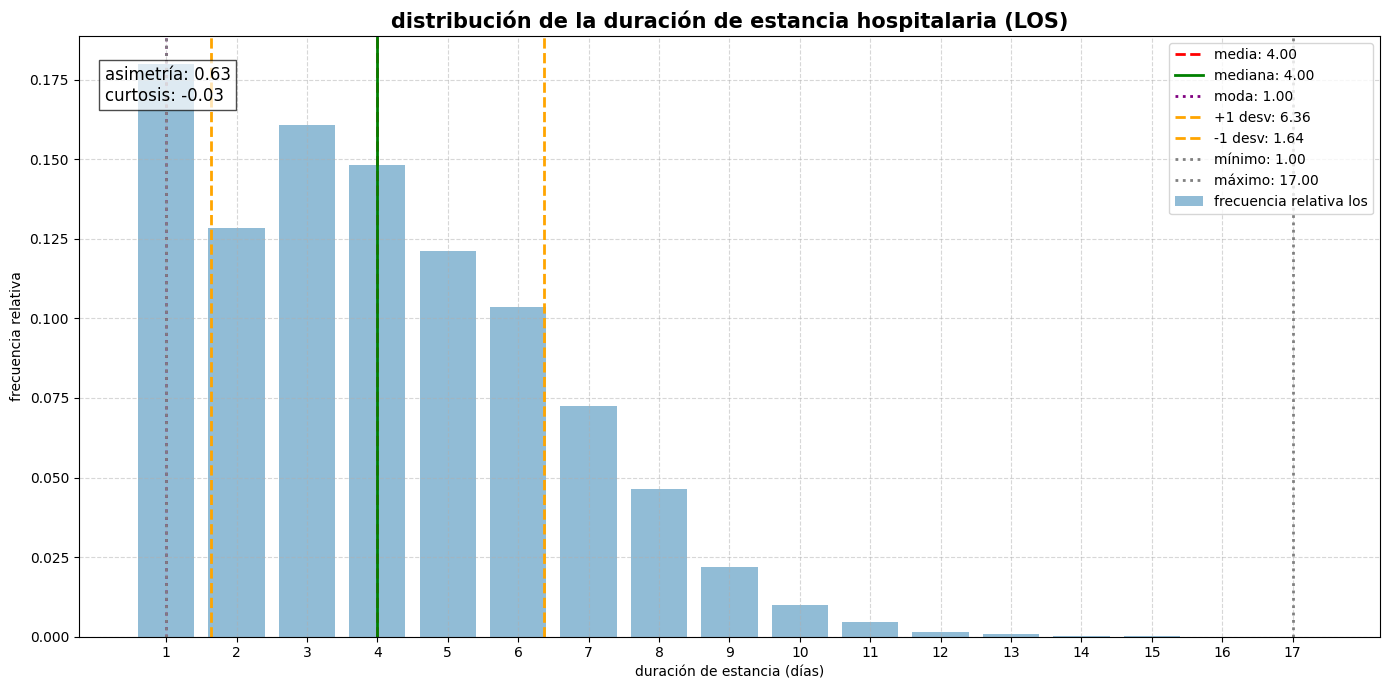

Media: 4.00
Mediana: 4.00
Moda: 1.00
Mínimo: 1.00
Máximo: 17.00
Desviación estándar: 2.36
Asimetría: 0.63
Curtosis: -0.03


In [3]:
# extraer la variable de interés
los = df_filtered['lengthofstay'].dropna().values

# medidas descriptivas
media = np.mean(los)  
mediana = np.median(los) 
moda = stats.mode(los, keepdims=True).mode[0]  
minimo = np.min(los)  
maximo = np.max(los)  
desviacion = np.std(los)  
asimetria = stats.skew(los)  
curtosis = stats.kurtosis(los)  

# para variable discreta, mejor usar gráfico de barras
valores, cuentas = np.unique(los, return_counts=True)

plt.figure(figsize=(14, 7))
plt.bar(valores, cuentas / cuentas.sum(), color="#91BCD6", label="frecuencia relativa los")  # frecuencia relativa

# líneas de referencia
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'mediana: {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'moda: {moda:.2f}')
plt.axvline(media + desviacion, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media+desviacion):.2f}')
plt.axvline(media - desviacion, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media-desviacion):.2f}')
plt.axvline(minimo, color='grey', linestyle=':', linewidth=2, label=f'mínimo: {minimo:.2f}')
plt.axvline(maximo, color='grey', linestyle=':', linewidth=2, label=f'máximo: {maximo:.2f}')
plt.xticks(valores)

# caja de texto con asimetría y curtosis
plt.text(0.02, 0.95, f'asimetría: {asimetria:.2f}\ncurtosis: {curtosis:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("distribución de la duración de estancia hospitalaria (LOS)", fontsize=15, weight="bold")
plt.xlabel("duración de estancia (días)")
plt.ylabel("frecuencia relativa")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda: {moda:.2f}")
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}")
print(f"Desviación estándar: {desviacion:.2f}")
print(f"Asimetría: {asimetria:.2f}")
print(f"Curtosis: {curtosis:.2f}")

### Interpretación

La media y la mediana de la duración de estancia hospitalaria son ambas de 4,00 días, lo que indica que la mayoría de los pacientes permanece alrededor de ese tiempo. La moda es 1,00 día, es decir, el valor más frecuente corresponde a estancias muy cortas. El rango va de 1,00 a 17,00 días, mostrando que existen tanto estancias mínimas como algunos casos considerablemente más largos.

La desviación estándar es 2,36 días, lo que refleja una dispersión moderada respecto a la media. La asimetría es 0,63, lo que indica una distribución desplazada a la derecha: predominan las estancias cortas, pero algunos pacientes presentan hospitalizaciones prolongadas que generan una cola más larga. La curtosis es -0,03, un valor cercano a cero que señala un nivel de concentración de la distribución similar al de una normal, aunque la asimetría evidencia que la forma global no es gaussiana.

En resumen, la mayoría de los pacientes tiene estancias cortas, mientras que unos pocos casos con hospitalizaciones más largas explican la dispersión y el sesgo hacia la derecha.

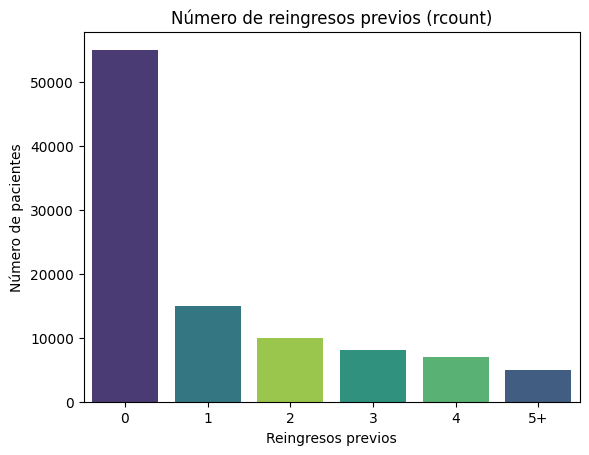

In [4]:
# Gráfico de barras: número de reingresos (rcount) ordenado
orden_rcount = ["0", "1", "2", "3", "4", "5+"]
sns.countplot(x='rcount', data=df_filtered, order=orden_rcount, hue='rcount', palette='viridis', legend=False)
plt.title("Número de reingresos previos (rcount)")
plt.xlabel("Reingresos previos")
plt.ylabel("Número de pacientes")
plt.show()


### Interpretación

En este gráfico se observa que la distribución de las readmisiones sigue una tendencia decreciente: la gran mayoría de los pacientes corresponde a su primera admisión, mientras que una proporción mucho menor presenta varias readmisiones, y solo un número muy reducido ha sido readmitido cinco veces o más.

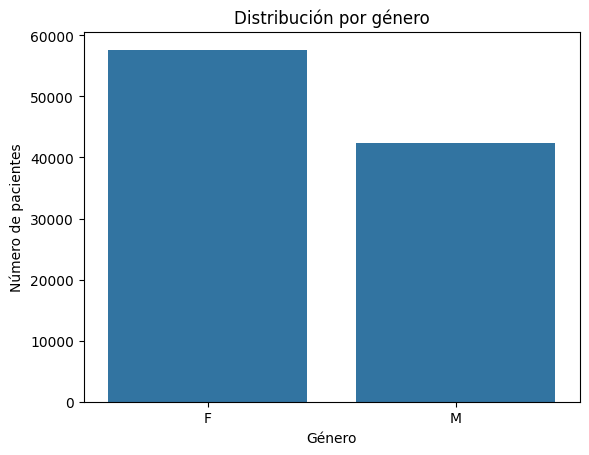

In [5]:
# Gráfico de barras: género
sns.countplot(x='gender', data=df_filtered)
plt.title("Distribución por género")
plt.xlabel("Género")
plt.ylabel("Número de pacientes")
plt.show()

### Interpretación  

Observamos una ligera mayoría de pacientes **mujeres** en los datos analizados.  
La distribución por género no es exactamente equilibrada (aproximadamente **58% mujeres frente a 42% hombres**), pero esta diferencia no representa un problema significativo, ya que contamos con un volumen muy amplio de datos.  
Al tratarse de una variable categórica, no requiere un análisis mucho más profundo en este punto, aunque es importante tenerla en cuenta para futuras comparaciones o posibles sesgos en los modelos.  

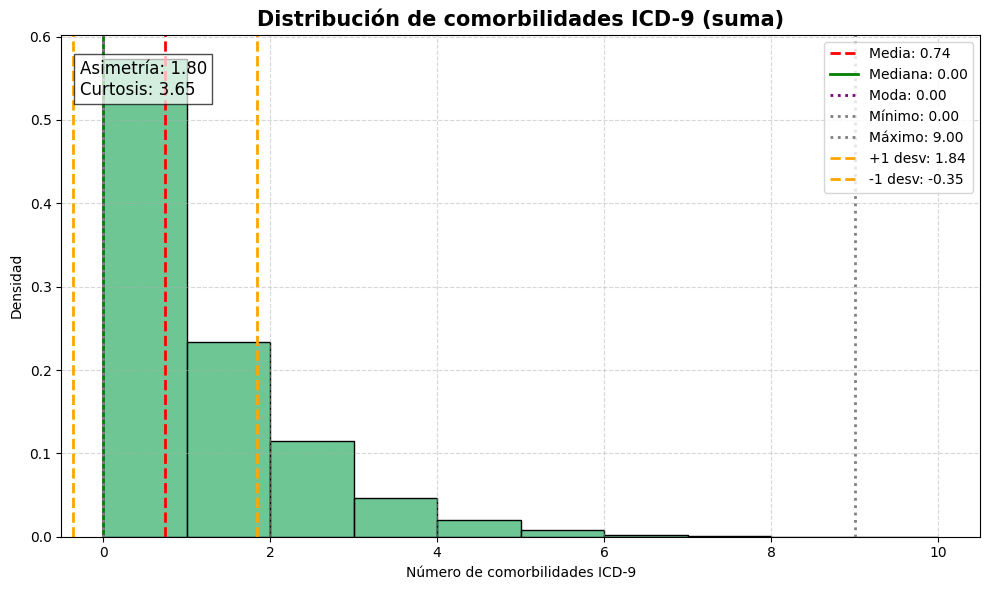

Media: 0.74
Mediana: 0.00
Moda: 0.00
Mínimo: 0.00
Máximo: 9.00
Desviación estándar: 1.10
Asimetría: 1.80
Curtosis: 3.65


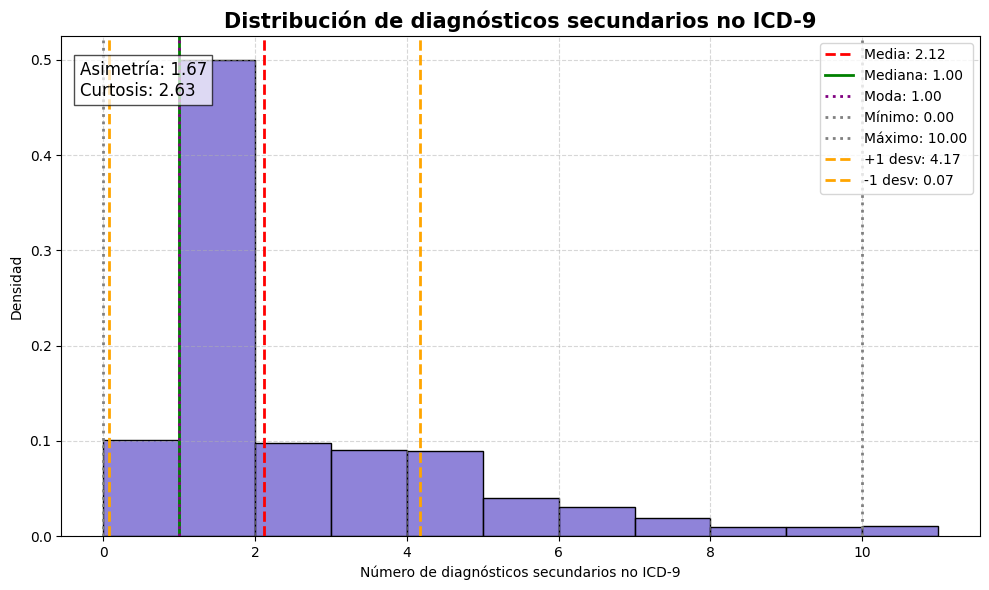

Media: 2.12
Mediana: 1.00
Moda: 1.00
Mínimo: 0.00
Máximo: 10.00
Desviación estándar: 2.05
Asimetría: 1.67
Curtosis: 2.63


In [7]:
# Histograma y estadísticas descriptivas para Comorbilidades ICD-9 (suma)

icd9_sum = df_filtered['icd9_comorbidity_sum'].dropna().values

media_icd9 = np.mean(icd9_sum)
mediana_icd9 = np.median(icd9_sum)
moda_icd9 = stats.mode(icd9_sum, keepdims=True).mode[0]
minimo_icd9 = np.min(icd9_sum)
maximo_icd9 = np.max(icd9_sum)
desviacion_icd9 = np.std(icd9_sum)
asimetria_icd9 = stats.skew(icd9_sum)
curtosis_icd9 = stats.kurtosis(icd9_sum)

plt.figure(figsize=(10, 6))
sns.histplot(icd9_sum, bins=range(int(minimo_icd9), int(maximo_icd9)+2), kde=False, color='mediumseagreen', edgecolor='black', stat='density')
plt.axvline(media_icd9, color='red', linestyle='--', linewidth=2, label=f'Media: {media_icd9:.2f}')
plt.axvline(mediana_icd9, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_icd9:.2f}')
plt.axvline(moda_icd9, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_icd9:.2f}')
plt.axvline(minimo_icd9, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_icd9:.2f}')
plt.axvline(maximo_icd9, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_icd9:.2f}')
plt.axvline(media_icd9 + desviacion_icd9, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_icd9+desviacion_icd9):.2f}')
plt.axvline(media_icd9 - desviacion_icd9, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_icd9-desviacion_icd9):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_icd9:.2f}\nCurtosis: {curtosis_icd9:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución de comorbilidades ICD-9 (suma)", fontsize=15, weight="bold")
plt.xlabel("Número de comorbilidades ICD-9")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_icd9:.2f}")
print(f"Mediana: {mediana_icd9:.2f}")
print(f"Moda: {moda_icd9:.2f}")
print(f"Mínimo: {minimo_icd9:.2f}")
print(f"Máximo: {maximo_icd9:.2f}")
print(f"Desviación estándar: {desviacion_icd9:.2f}")
print(f"Asimetría: {asimetria_icd9:.2f}")
print(f"Curtosis: {curtosis_icd9:.2f}")

# Histograma para diagnósticos secundarios ICD-9
sec_diag = df_filtered['secondarydiagnosisnonicd9'].dropna().values

media_sec = np.mean(sec_diag)
mediana_sec = np.median(sec_diag)
moda_sec = stats.mode(sec_diag, keepdims=True).mode[0]
minimo_sec = np.min(sec_diag)
maximo_sec = np.max(sec_diag)
desviacion_sec = np.std(sec_diag)
asimetria_sec = stats.skew(sec_diag)
curtosis_sec = stats.kurtosis(sec_diag)

plt.figure(figsize=(10, 6))
sns.histplot(sec_diag, bins=range(int(minimo_sec), int(maximo_sec)+2), kde=False, color='slateblue', edgecolor='black', stat='density')
plt.axvline(media_sec, color='red', linestyle='--', linewidth=2, label=f'Media: {media_sec:.2f}')
plt.axvline(mediana_sec, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_sec:.2f}')
plt.axvline(moda_sec, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_sec:.2f}')
plt.axvline(minimo_sec, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_sec:.2f}')
plt.axvline(maximo_sec, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_sec:.2f}')
plt.axvline(media_sec + desviacion_sec, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_sec+desviacion_sec):.2f}')
plt.axvline(media_sec - desviacion_sec, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_sec-desviacion_sec):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_sec:.2f}\nCurtosis: {curtosis_sec:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución de diagnósticos secundarios no ICD-9", fontsize=15, weight="bold")
plt.xlabel("Número de diagnósticos secundarios no ICD-9")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_sec:.2f}")
print(f"Mediana: {mediana_sec:.2f}")
print(f"Moda: {moda_sec:.2f}")
print(f"Mínimo: {minimo_sec:.2f}")
print(f"Máximo: {maximo_sec:.2f}")
print(f"Desviación estándar: {desviacion_sec:.2f}")
print(f"Asimetría: {asimetria_sec:.2f}")
print(f"Curtosis: {curtosis_sec:.2f}")

### Interpretación

En la primera gráfica, correspondiente a la **suma de comorbilidades ICD-9**, observamos una distribución muy asimétrica hacia la derecha (asimetría = 1.80), con la gran mayoría de los pacientes concentrados en valores bajos (0 o 1 comorbilidad).  
La curtosis elevada (3.65) indica la presencia de colas más pesadas de lo esperado en una distribución normal, lo que confirma que existen algunos casos extremos con un número relativamente alto de comorbilidades, aunque son poco frecuentes.  
En resumen, la mayoría de los pacientes presenta pocas comorbilidades relevantes, pero existe un pequeño grupo con mayor carga clínica que puede tener un impacto significativo en la duración de la estancia hospitalaria.

En la segunda gráfica, que muestra la distribución de **diagnósticos secundarios no ICD-9**, se aprecia un patrón similar: fuerte asimetría positiva (1.67) y curtosis también elevada (2.63).  
La mayoría de los pacientes tiene entre 0 y 2 diagnósticos secundarios, pero hay casos aislados que alcanzan hasta 10. Estos valores extremos sugieren la existencia de pacientes más complejos y con mayor riesgo clínico.  

En conjunto, ambas variables reflejan la heterogeneidad clínica de los pacientes: mientras la mayoría presenta pocas condiciones adicionales, los casos con múltiples comorbilidades o diagnósticos secundarios pueden jugar un papel clave en la predicción de la duración de la hospitalización.


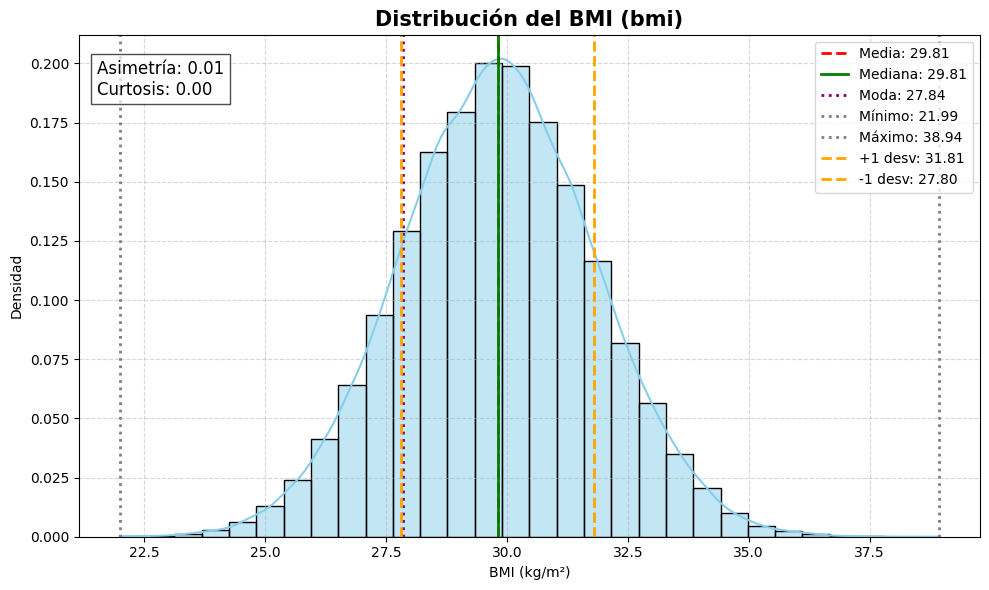

Media: 29.81
Mediana: 29.81
Moda: 27.84
Mínimo: 21.99
Máximo: 38.94
Desviación estándar: 2.00
Asimetría: 0.01
Curtosis: 0.00


In [8]:
# Histograma y estadísticas descriptivas para BMI

bmi = df_filtered['bmi'].dropna().values

# Cálculos estadísticos
media_bmi = np.mean(bmi)
mediana_bmi = np.median(bmi)
moda_bmi = stats.mode(bmi, keepdims=True).mode[0]
minimo_bmi = np.min(bmi)
maximo_bmi = np.max(bmi)
desviacion_bmi = np.std(bmi)
asimetria_bmi = stats.skew(bmi)
curtosis_bmi = stats.kurtosis(bmi)

# Histograma con KDE
plt.figure(figsize=(10, 6))
sns.histplot(bmi, bins=30, kde=True, color='skyblue', stat='density', edgecolor='black')
plt.axvline(media_bmi, color='red', linestyle='--', linewidth=2, label=f'Media: {media_bmi:.2f}')
plt.axvline(mediana_bmi, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_bmi:.2f}')
plt.axvline(moda_bmi, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_bmi:.2f}')
plt.axvline(minimo_bmi, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_bmi:.2f}')
plt.axvline(maximo_bmi, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_bmi:.2f}')
plt.axvline(media_bmi + desviacion_bmi, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_bmi+desviacion_bmi):.2f}')
plt.axvline(media_bmi - desviacion_bmi, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_bmi-desviacion_bmi):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_bmi:.2f}\nCurtosis: {curtosis_bmi:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución del BMI (bmi)", fontsize=15, weight="bold")
plt.xlabel("BMI (kg/m²)")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_bmi:.2f}")
print(f"Mediana: {mediana_bmi:.2f}")
print(f"Moda: {moda_bmi:.2f}")
print(f"Mínimo: {minimo_bmi:.2f}")
print(f"Máximo: {maximo_bmi:.2f}")
print(f"Desviación estándar: {desviacion_bmi:.2f}")
print(f"Asimetría: {asimetria_bmi:.2f}")
print(f"Curtosis: {curtosis_bmi:.2f}")


### Interpretación

Según la asimetría y la curtosis, la distribución del IMC (BMI) es bastante cercana a una distribución normal y simétrica. La media se sitúa alrededor de 29,8, un valor elevado si consideramos que un IMC saludable está entre 19 y 25. Sin embargo, esto es coherente con la realidad de la población estadounidense, donde estudios recientes (2020) reportan un IMC medio cercano a 30.

La desviación estándar es relativamente baja en comparación con la media, lo que indica que la mayoría de los valores no se alejan mucho del promedio. No obstante, el rango observado (aproximadamente de 22 a 39) muestra la presencia de valores extremos, tanto por debajo como por encima de la media. Estos valores extremos pueden estar asociados a casos de desnutrición o de obesidad severa, condiciones que, según la literatura, suelen estar relacionadas con estancias hospitalarias más prolongadas.

En resumen, la distribución del IMC en este conjunto de datos refleja la tendencia de la población general, con una mayoría de pacientes en rangos de sobrepeso u obesidad, y algunos casos extremos que podrían influir en la duración de la estancia hospitalaria.œ

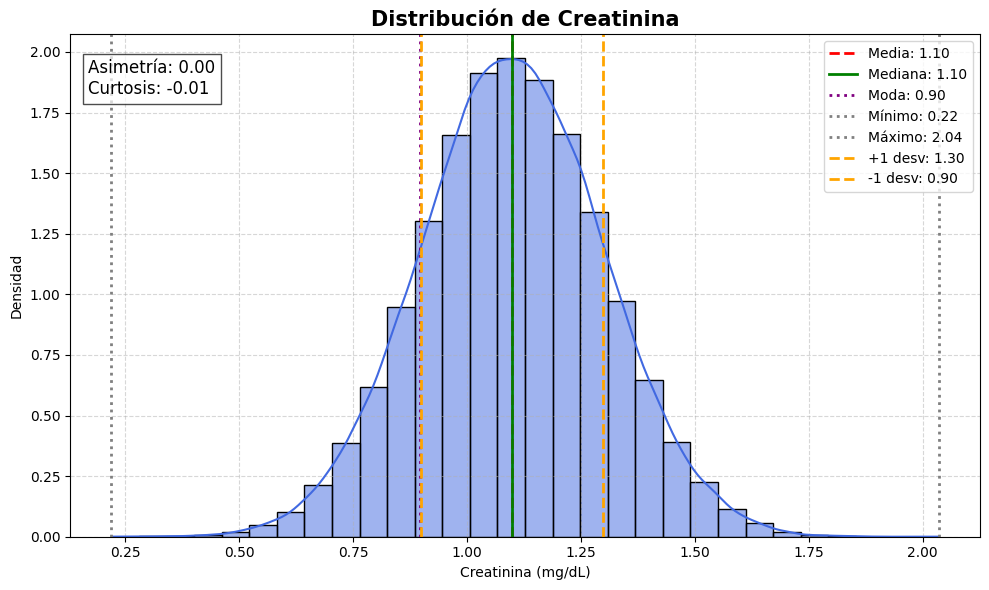

Media: 1.10
Mediana: 1.10
Moda: 0.90
Mínimo: 0.22
Máximo: 2.04
Desviación estándar: 0.20
Asimetría: 0.00
Curtosis: -0.01


In [9]:
# Histograma y estadísticas descriptivas para Creatinina

creatinina = df_filtered['creatinine'].dropna().values

# Cálculos estadísticos
media_creat = np.mean(creatinina)
mediana_creat = np.median(creatinina)
moda_creat = stats.mode(creatinina, keepdims=True).mode[0]
minimo_creat = np.min(creatinina)
maximo_creat = np.max(creatinina)
desviacion_creat = np.std(creatinina)
asimetria_creat = stats.skew(creatinina)
curtosis_creat = stats.kurtosis(creatinina)

# Histograma con KDE
plt.figure(figsize=(10, 6))
sns.histplot(creatinina, bins=30, kde=True, color='royalblue', stat='density', edgecolor='black')
plt.axvline(media_creat, color='red', linestyle='--', linewidth=2, label=f'Media: {media_creat:.2f}')
plt.axvline(mediana_creat, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_creat:.2f}')
plt.axvline(moda_creat, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_creat:.2f}')
plt.axvline(minimo_creat, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_creat:.2f}')
plt.axvline(maximo_creat, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_creat:.2f}')
plt.axvline(media_creat + desviacion_creat, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_creat+desviacion_creat):.2f}')
plt.axvline(media_creat - desviacion_creat, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_creat-desviacion_creat):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_creat:.2f}\nCurtosis: {curtosis_creat:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución de Creatinina", fontsize=15, weight="bold")
plt.xlabel("Creatinina (mg/dL)")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_creat:.2f}")
print(f"Mediana: {mediana_creat:.2f}")
print(f"Moda: {moda_creat:.2f}")
print(f"Mínimo: {minimo_creat:.2f}")
print(f"Máximo: {maximo_creat:.2f}")
print(f"Desviación estándar: {desviacion_creat:.2f}")
print(f"Asimetría: {asimetria_creat:.2f}")
print(f"Curtosis: {curtosis_creat:.2f}")

### Interpretación  

La distribución de la creatinina muestra un comportamiento muy cercano a una distribución normal. La media (1.10), la mediana (1.10) y la moda (0.90) están muy próximas entre sí, lo que indica simetría en torno al valor central. Además, la asimetría reportada es prácticamente nula (0.00) y la curtosis (-0.01) se encuentra muy cercana a la de una distribución normal, lo que confirma la ausencia de sesgos significativos y de colas excesivamente pesadas.  

La desviación estándar (0.20) es baja en relación con la media, lo que refleja que la mayoría de los valores se concentran en un rango estrecho, entre aproximadamente 0.9 y 1.3 mg/dL. El rango observado (0.22 a 2.04 mg/dL) incluye algunos valores más extremos, pero estos no afectan de manera relevante la forma global de la distribución.  

En resumen, los datos de creatinina presentan una distribución aproximadamente normal, simétrica y con una variabilidad reducida, lo que sugiere que la mayoría de los individuos se encuentran en rangos fisiológicos estables y sin la influencia de valores atípicos extremos.  


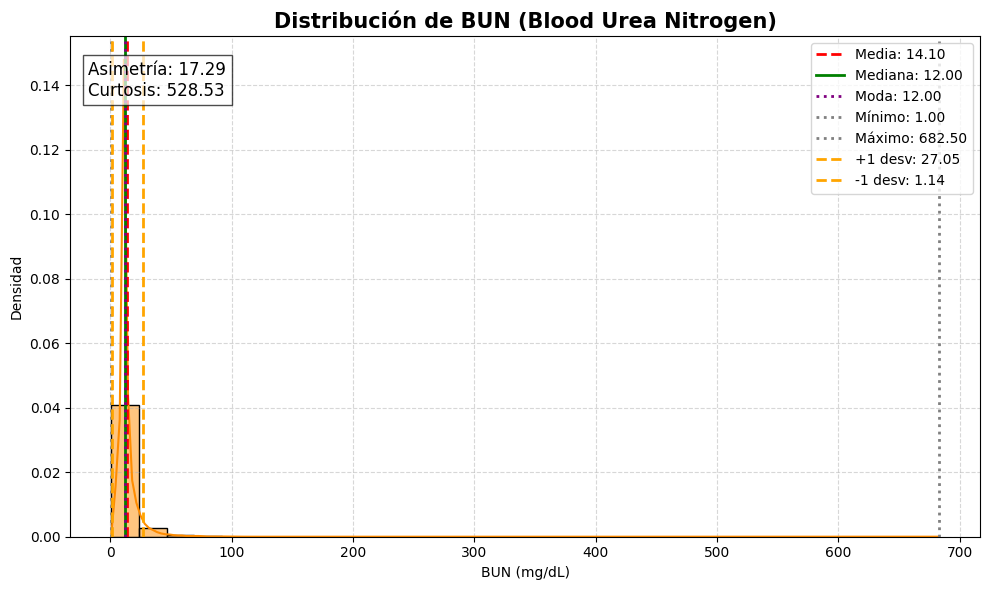

Media: 14.10
Mediana: 12.00
Moda: 12.00
Mínimo: 1.00
Máximo: 682.50
Desviación estándar: 12.95
Asimetría: 17.29
Curtosis: 528.53


In [10]:
bun = df_filtered['bloodureanitro'].dropna().values

# estadísticos
media_bun = np.mean(bun)
mediana_bun = np.median(bun)
moda_bun = stats.mode(bun, keepdims=True).mode[0]
minimo_bun = np.min(bun)
maximo_bun = np.max(bun)
desviacion_bun = np.std(bun)
asimetria_bun = stats.skew(bun)
curtosis_bun = stats.kurtosis(bun)

plt.figure(figsize=(10, 6))
sns.histplot(bun, bins=30, kde=True, color='darkorange', stat='density', edgecolor='black')
plt.axvline(media_bun, color='red', linestyle='--', linewidth=2, label=f'Media: {media_bun:.2f}')
plt.axvline(mediana_bun, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_bun:.2f}')
plt.axvline(moda_bun, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_bun:.2f}')
plt.axvline(minimo_bun, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_bun:.2f}')
plt.axvline(maximo_bun, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_bun:.2f}')
plt.axvline(media_bun + desviacion_bun, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_bun+desviacion_bun):.2f}')
plt.axvline(media_bun - desviacion_bun, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_bun-desviacion_bun):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_bun:.2f}\nCurtosis: {curtosis_bun:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución de BUN (Blood Urea Nitrogen)", fontsize=15, weight="bold")
plt.xlabel("BUN (mg/dL)")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_bun:.2f}")
print(f"Mediana: {mediana_bun:.2f}")
print(f"Moda: {moda_bun:.2f}")
print(f"Mínimo: {minimo_bun:.2f}")
print(f"Máximo: {maximo_bun:.2f}")
print(f"Desviación estándar: {desviacion_bun:.2f}")
print(f"Asimetría: {asimetria_bun:.2f}")
print(f"Curtosis: {curtosis_bun:.2f}")

### Interpretación  

Según los estadísticos descriptivos, la distribución del BUN (Blood Urea Nitrogen) parece concentrarse en torno a valores bajos, con una media de 14.1 y una mediana de 12, lo que sugiere que la mayoría de los pacientes presentan niveles dentro de un rango relativamente normal. Sin embargo, la asimetría extremadamente alta (17.29) y la curtosis excesiva (528.53) indican que la distribución está fuertemente sesgada hacia la derecha y presenta colas muy pesadas. Esto significa que existen valores atípicos muy elevados, como el máximo de 682.5 mg/dL, que distorsionan notablemente la forma de la curva. La desviación estándar (12.95) es moderada en comparación con la media, lo que confirma que la variabilidad central no es excesiva, pero la dispersión hacia valores altos resulta desproporcionada.  

En resumen, aunque la mayor parte de los casos se concentran alrededor de 12–14 mg/dL, la presencia de outliers extremos genera una distribución no normal, con sesgo positivo marcado y curtosis muy elevada, lo que debe ser considerado cuidadosamente en cualquier análisis estadístico posterior.  


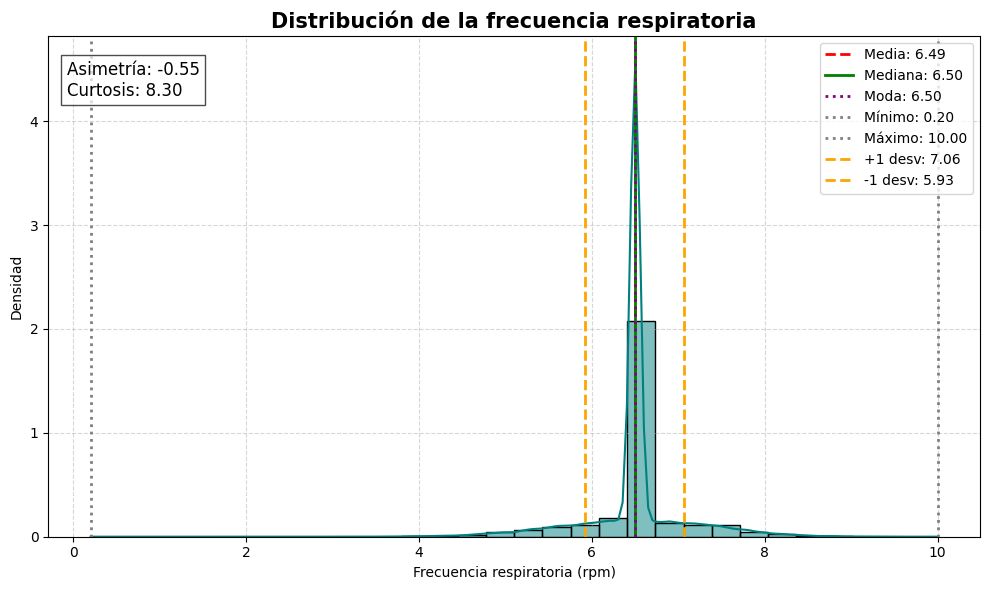

Media: 6.49
Mediana: 6.50
Moda: 6.50
Mínimo: 0.20
Máximo: 10.00
Desviación estándar: 0.57
Asimetría: -0.55
Curtosis: 8.30


In [11]:
resp = df_filtered['respiration'].dropna().values

media_resp = np.mean(resp)
mediana_resp = np.median(resp)
moda_resp = stats.mode(resp, keepdims=True).mode[0]
minimo_resp = np.min(resp)
maximo_resp = np.max(resp)
desviacion_resp = np.std(resp)
asimetria_resp = stats.skew(resp)
curtosis_resp = stats.kurtosis(resp)

plt.figure(figsize=(10, 6))
sns.histplot(resp, bins=30, kde=True, color='teal', stat='density', edgecolor='black')
plt.axvline(media_resp, color='red', linestyle='--', linewidth=2, label=f'Media: {media_resp:.2f}')
plt.axvline(mediana_resp, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_resp:.2f}')
plt.axvline(moda_resp, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda_resp:.2f}')
plt.axvline(minimo_resp, color='grey', linestyle=':', linewidth=2, label=f'Mínimo: {minimo_resp:.2f}')
plt.axvline(maximo_resp, color='grey', linestyle=':', linewidth=2, label=f'Máximo: {maximo_resp:.2f}')
plt.axvline(media_resp + desviacion_resp, color='orange', linestyle='--', linewidth=2, label=f'+1 desv: {(media_resp+desviacion_resp):.2f}')
plt.axvline(media_resp - desviacion_resp, color='orange', linestyle='--', linewidth=2, label=f'-1 desv: {(media_resp-desviacion_resp):.2f}')

plt.text(0.02, 0.95, f'Asimetría: {asimetria_resp:.2f}\nCurtosis: {curtosis_resp:.2f}',
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.title("Distribución de la frecuencia respiratoria", fontsize=15, weight="bold")
plt.xlabel("Frecuencia respiratoria (rpm)")
plt.ylabel("Densidad")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Media: {media_resp:.2f}")
print(f"Mediana: {mediana_resp:.2f}")
print(f"Moda: {moda_resp:.2f}")
print(f"Mínimo: {minimo_resp:.2f}")
print(f"Máximo: {maximo_resp:.2f}")
print(f"Desviación estándar: {desviacion_resp:.2f}")
print(f"Asimetría: {asimetria_resp:.2f}")
print(f"Curtosis: {curtosis_resp:.2f}")

### Interpretación

Según los estadísticos descriptivos, la distribución de la **frecuencia respiratoria** se concentra en torno a valores moderados, con una media y mediana de 6.5 respiraciones por minuto, lo que indica que la mayoría de los pacientes presentan frecuencias dentro de un rango fisiológico habitual. La moda coincide con la mediana, reforzando la idea de una concentración central de los datos.

Sin embargo, la asimetría negativa (-0.55) revela una ligera inclinación hacia valores más bajos, es decir, existen algunos pacientes con frecuencias respiratorias inferiores al promedio. La curtosis elevada (8.30) indica colas más pesadas de lo esperado en una distribución normal, lo que sugiere la presencia de valores extremos, especialmente en el extremo inferior (mínimo de 0.20 rpm).

La desviación estándar es baja (0.57), lo que confirma que la mayoría de los valores están próximos a la media, aunque los valores atípicos contribuyen a una mayor concentración en los extremos.

En resumen, la distribución es relativamente simétrica pero con una leve tendencia hacia frecuencias bajas y una curtosis alta que refleja la existencia de algunos casos extremos. Estos valores atípicos deben analizarse cuidadosamente, ya que podrían corresponder a situaciones clínicas particulares o a posibles errores de registro.

## III.B - Bivariadas

Como primer paso en el análisis bivariado, vamos a realizar un **pairplot** entre las variables continuas seleccionadas. Este tipo de visualización nos permite explorar las relaciones y posibles dependencias entre pares de variables, además de observar sus distribuciones individuales.  

Para facilitar la visualización y evitar tener 17 colores distintos en el gráfico, decidimos **agrupar la variable de duración de estancia (LOS) en tres categorías**:  
- **corto:** 0–2 días  
- **medio:** 3–7 días  
- **largo:** 8+ días  

De esta manera, el pairplot resulta mucho más claro y permite observar mejor las posibles tendencias o patrones entre las variables continuas seleccionadas (**BMI, creatinina, BUN y frecuencia respiratoria**).  

Esta estrategia de agrupación no solo mejora la legibilidad del gráfico, sino que también facilita la comparación entre pacientes con estancias de distinta duración, lo que podría revelar relaciones interesantes entre las variables clínicas y el tiempo total de hospitalización.


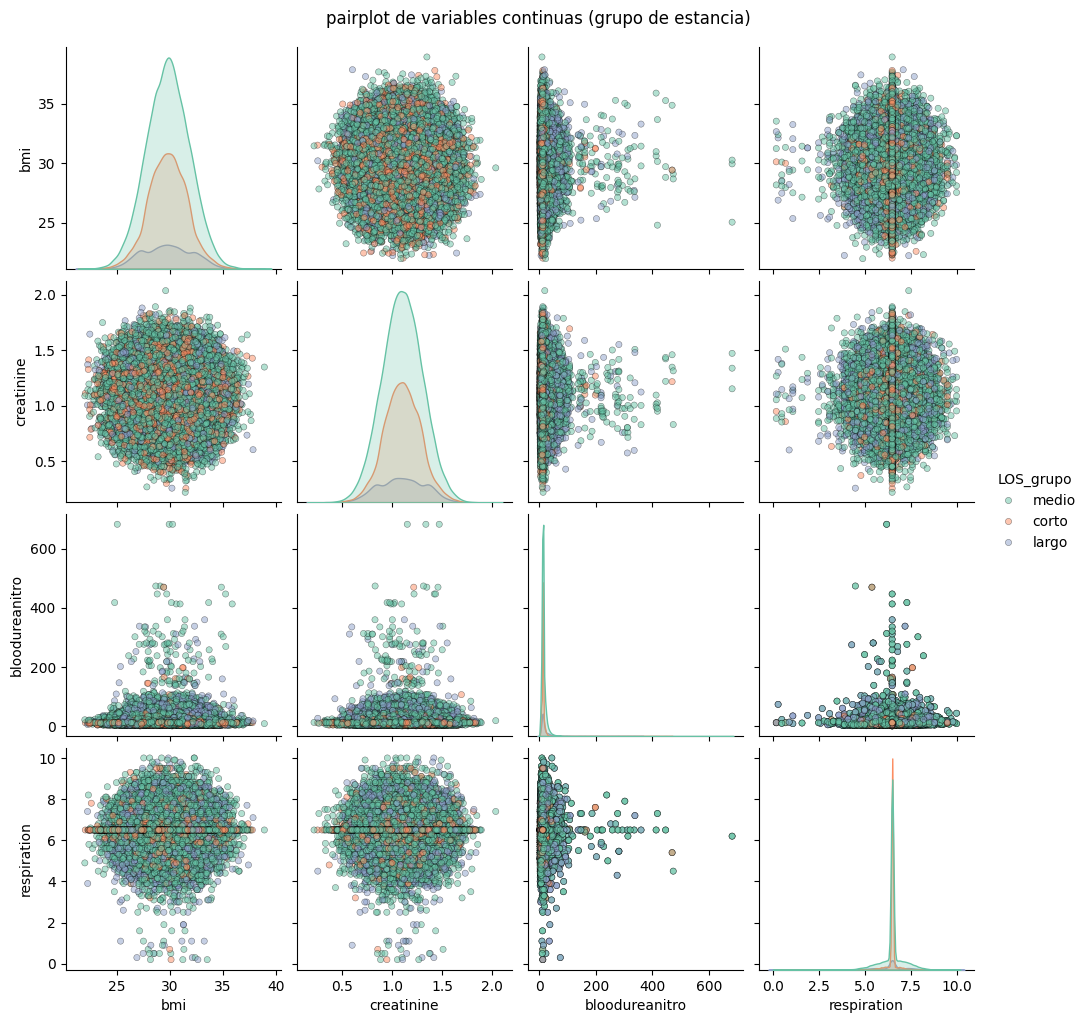

In [12]:
# agrupamos los pacientes en 3 grupos según los días de estancia
# corto: 0-2 días, medio: 3-7 días, largo: 8+ días
def categorizar_los(los):
    if los <= 2:
        return 'corto'
    elif los <= 7:
        return 'medio'
    else:
        return 'largo'

df_filtered['LOS_grupo'] = df_filtered['lengthofstay'].apply(categorizar_los)
vars_continues = ['bmi', 'creatinine', 'bloodureanitro', 'respiration']
sns.pairplot(
    df_filtered,
    vars=vars_continues,
    hue='LOS_grupo',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha':0.5, 's':20, 'edgecolor':'k'}
)
plt.suptitle('pairplot de variables continuas (grupo de estancia)', y=1.02)
plt.show()

### Interpretación

El pairplot muestra las relaciones entre las cuatro variables continuas (**BMI, creatinina, BUN y frecuencia respiratoria**) según los grupos de duración de estancia (**corta, media y larga**).  

En general, no se observa una separación clara entre los grupos de estancia: los puntos están muy mezclados y no aparece una tendencia evidente que relacione directamente estas variables con la duración de la hospitalización. Esto sugiere que, de forma individual, estas variables no son suficientes para discriminar la duración de la estancia.  

Sin embargo, se puede intuir una ligera tendencia en la **frecuencia respiratoria**, donde los pacientes con valores más bajos parecen concentrarse algo más en el grupo de estancias largas. Aunque esta observación no es concluyente, podría indicar que una respiración reducida se asocia con una mayor gravedad clínica y, por lo tanto, con una estancia hospitalaria más prolongada.  


A continuación, analizaremos **la relación entre el número de reingresos (rcount) y distintas variables discretas**.  
El objetivo es examinar si ciertos factores, como la duración de la estancia, la presencia de comorbilidades (ICD-9), el género o los diagnósticos secundarios no codificados en ICD-9, están asociados con un mayor número de reingresos.  

Para ello, utilizamos una serie de **countplots** que permiten visualizar la distribución de los pacientes según el número de reingresos y su desagregación por cada una de estas variables.  


Pearson: coef = -0.022, p-valor = 1.79e-12
Spearman: coef = 0.001, p-valor = 0.66


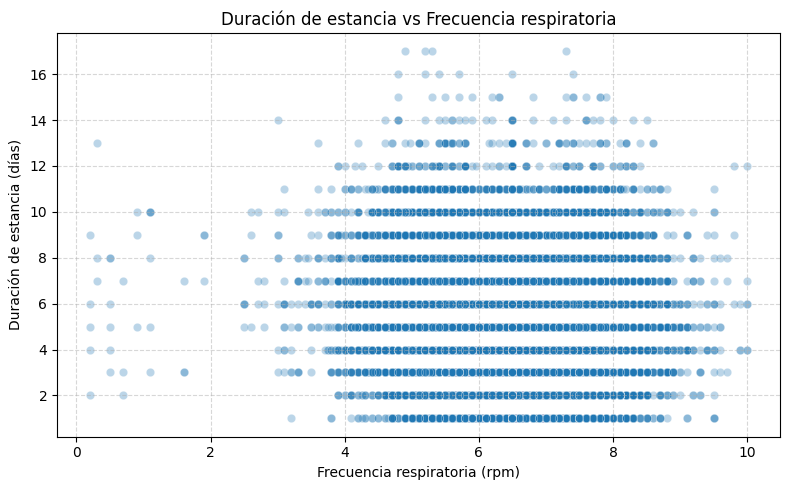

In [13]:
resp = df_filtered['respiration'].dropna()
los = df_filtered.loc[resp.index, 'lengthofstay']

# Pearson (correlación lineal)
pearson_coef, pearson_p = pearsonr(resp, los)
print(f"Pearson: coef = {pearson_coef:.3f}, p-valor = {pearson_p:.3g}")

# Spearman (correlación de rango)
spearman_coef, spearman_p = spearmanr(resp, los)
print(f"Spearman: coef = {spearman_coef:.3f}, p-valor = {spearman_p:.3g}")

plt.figure(figsize=(8,5))
sns.scatterplot(x=resp, y=los, alpha=0.3)
plt.title("Duración de estancia vs Frecuencia respiratoria")
plt.xlabel("Frecuencia respiratoria (rpm)")
plt.ylabel("Duración de estancia (días)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretación

Los resultados de la correlación entre la **frecuencia respiratoria** y la **duración de la estancia hospitalaria (LOS)** muestran lo siguiente:

- **Pearson:** coeficiente = -0.022, p-valor = 1.79e-12  
- **Spearman:** coeficiente = 0.001, p-valor = 0.66

**Interpretación:**

El coeficiente de Pearson es muy cercano a cero y negativo, lo que indica que **no existe una relación lineal significativa** entre la frecuencia respiratoria y la duración de la estancia hospitalaria. Aunque el p-valor es muy bajo (debido al gran tamaño de la muestra), la magnitud del coeficiente es prácticamente nula, por lo que la asociación no es relevante en la práctica.

El coeficiente de Spearman también es casi cero y el p-valor es alto (0.66), lo que confirma que **no hay una relación monotónica** (ni creciente ni decreciente) entre ambas variables.

**Conclusión:**  
En este conjunto de datos, la frecuencia respiratoria **no predice ni está asociada de manera significativa** con la duración de la estancia hospitalaria. Esto sugiere que otros factores clínicos tienen mayor peso en la determinación del tiempo de hospitalización.

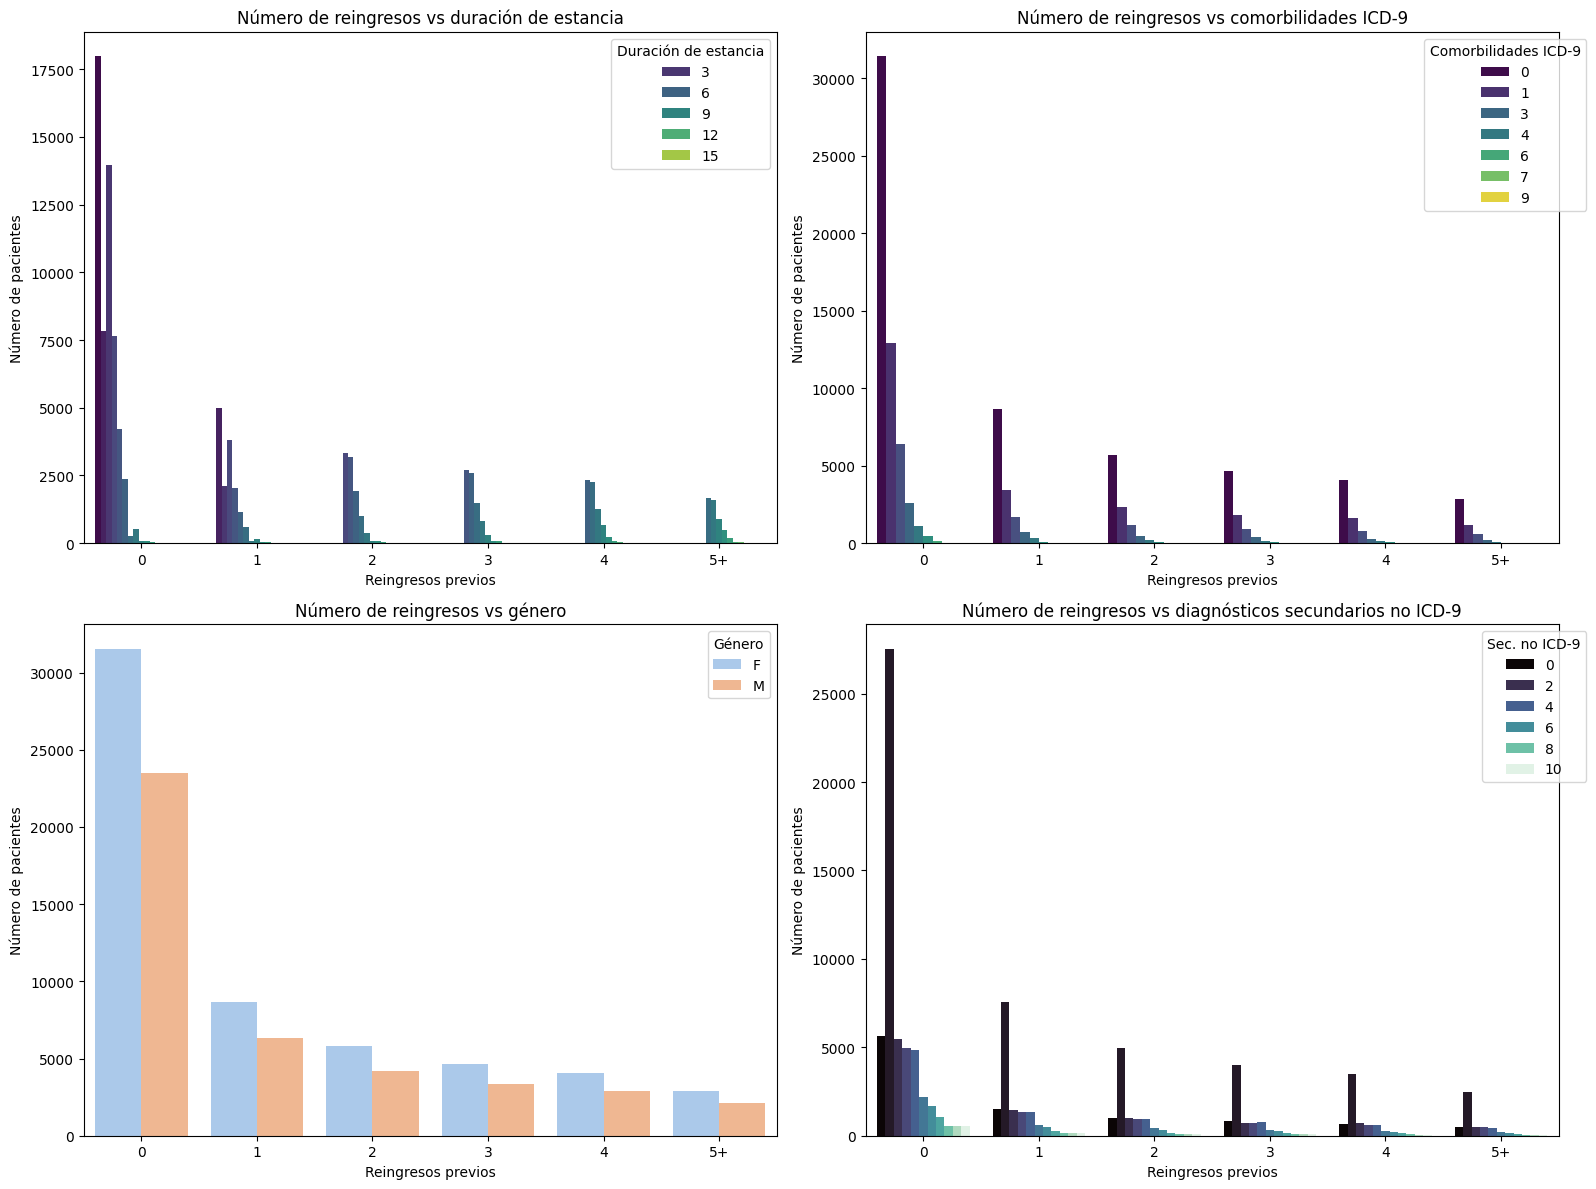

In [14]:
# cuatro gráficos countplot: rcount vs lengthofstay, rcount vs icd9_comorbidity_sum,
# rcount vs gender, rcount vs secondarydiagnosisnonicd9

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

orden_rcount = ["0", "1", "2", "3", "4", "5+"]

# rcount vs lengthofstay
g1 = sns.countplot(x='rcount', data=df_filtered, order=orden_rcount, hue='lengthofstay', palette='viridis', ax=axs[0,0])
axs[0,0].set_title("Número de reingresos vs duración de estancia")
axs[0,0].set_xlabel("Reingresos previos")
axs[0,0].set_ylabel("Número de pacientes")
axs[0,0].legend(title="Duración de estancia", loc='upper right')

# rcount vs icd9_comorbidity_sum
g2 = sns.countplot(x='rcount', data=df_filtered, order=orden_rcount, hue='icd9_comorbidity_sum', palette='viridis', ax=axs[0,1])
axs[0,1].set_title("Número de reingresos vs comorbilidades ICD-9")
axs[0,1].set_xlabel("Reingresos previos")
axs[0,1].set_ylabel("Número de pacientes")
axs[0,1].legend(title="Comorbilidades ICD-9", loc='upper right', bbox_to_anchor=(1.05, 1))

# rcount vs gender
g3 = sns.countplot(x='rcount', data=df_filtered, order=orden_rcount, hue='gender', palette='pastel', ax=axs[1,0])
axs[1,0].set_title("Número de reingresos vs género")
axs[1,0].set_xlabel("Reingresos previos")
axs[1,0].set_ylabel("Número de pacientes")
axs[1,0].legend(title="Género", loc='upper right')

# rcount vs secondarydiagnosisnonicd9
g4 = sns.countplot(x='rcount', data=df_filtered, order=orden_rcount, hue='secondarydiagnosisnonicd9', palette='mako', ax=axs[1,1])
axs[1,1].set_title("Número de reingresos vs diagnósticos secundarios no ICD-9")
axs[1,1].set_xlabel("Reingresos previos")
axs[1,1].set_ylabel("Número de pacientes")
axs[1,1].legend(title="Sec. no ICD-9", loc='upper right', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

### Interpretación

Los gráficos muestran que la distribución de las readmisiones refleja en gran medida la composición del conjunto de datos: se observa una mayor proporción de hombres y la mayoría de los pacientes presentan dos diagnósticos secundarios no ICD-9. Sin embargo, destaca un aspecto relevante: los pacientes con más de cinco readmisiones tienden a tener estancias hospitalarias más prolongadas, lo que sugiere una relación entre la frecuencia de las readmisiones y la duración de la hospitalización. Además, las comorbilidades y los diagnósticos secundarios parecen influir menos en la variabilidad de las readmisiones, lo que indica que podrían intervenir otros factores no representados en estos gráficos.



Para visualizar de manera más precisa la relación entre el número de reingresos (rcount) y la duración de la estancia hospitalaria (LOS), podemos utilizar un boxplot. Este tipo de gráfico permite comparar la distribución de los días de hospitalización para cada categoría de reingresos, mostrando la mediana, la dispersión y la presencia de valores atípicos en cada grupo. Así, obtenemos una visión clara de cómo evoluciona la duración de la estancia en función del número de reingresos.

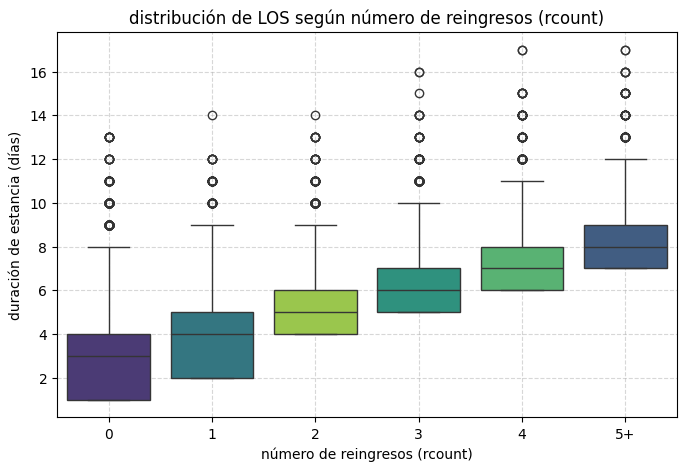

In [15]:
plt.figure(figsize=(8,5))
orden_rcount = ["0", "1", "2", "3", "4", "5+"]
sns.boxplot(x='rcount', y='lengthofstay', data=df_filtered, order=orden_rcount, hue='rcount', palette='viridis', dodge=False, legend=False)
plt.title('distribución de LOS según número de reingresos (rcount)')
plt.xlabel('número de reingresos (rcount)')
plt.ylabel('duración de estancia (días)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend([],[], frameon=False) 
plt.show()

### Interpretación  

El gráfico muestra una relación clara entre el número de reingresos (**rcount**) y la duración de la estancia hospitalaria (**LOS**). En general, a medida que aumenta el número de reingresos, la mediana de los días de hospitalización también se incrementa.  

Los pacientes que no presentan reingresos (rcount = 0) tienen estancias cortas, con una mediana cercana a los 3 días. En cambio, aquellos con 1 o 2 reingresos ya presentan estancias más largas (4 a 6 días). A partir de 3 y especialmente en las categorías de 4 y 5+, se observa un aumento progresivo, alcanzando medianas de entre 7 y 8 días, además de una mayor dispersión en los valores.  

Otro aspecto relevante es la presencia de **valores atípicos en la parte superior de la distribución**, es decir, pacientes con estancias hospitalarias muy largas en todas las categorías. En cambio, no se observan valores extremos por debajo, lo que indica que el límite inferior de los días de estancia es más estable mientras que el superior varía considerablemente.


In [16]:
tabla1 = pd.crosstab(df_filtered['icd9_comorbidity_sum'], df_filtered['secondarydiagnosisnonicd9'])
from IPython.display import display, HTML
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(HTML("<b>Tabla de contingencia (ICD-9 vs Sec. no ICD-9):</b>"))
    display(HTML(tabla1.to_html()))

secondarydiagnosisnonicd9,0,1,2,3,4,5,6,7,8,9,10
icd9_comorbidity_sum,,,,,,,,,,,
0,5825,28737,5640,5148,5137,2296,1738,1084,581,557,598
1,2379,11624,2301,2082,2088,915,750,501,240,241,229
2,1171,5787,1066,1079,1063,470,353,211,95,118,123
3,448,2292,441,434,443,185,154,102,55,45,61
4,180,1025,205,185,174,74,57,45,23,25,25
5,57,402,96,61,57,31,28,11,10,10,10
6,28,130,26,27,21,10,6,6,1,3,3
7,0,27,5,3,5,5,0,0,0,1,0
8,1,4,2,1,2,1,0,0,1,0,0


In [17]:
chi2_1, p_1, dof_1, expected_1 = chi2_contingency(tabla1)
print(f"Chi2 = {chi2_1:.3f}, p-valor = {p_1:.3f}")
print("Grados de libertad:", dof_1)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(HTML("<b>Frecuencias esperadas:</b>"))
    display(HTML(pd.DataFrame(expected_1, index=tabla1.index, columns=tabla1.columns).to_html()))


Chi2 = 120.730, p-valor = 0.017
Grados de libertad: 90


secondarydiagnosisnonicd9,0,1,2,3,4,5,6,7,8,9,10
icd9_comorbidity_sum,,,,,,,,,,,
0,5785.7069,28687.12889,5609.09662,5172.1582,5154.9559,2286.18567,1769.54326,1123.8836,576.85046,573.98341,601.50709
1,2356.0150,11681.77150,2284.09700,2106.1700,2099.1650,930.96450,720.58100,457.6600,234.90100,233.73350,244.94150
2,1163.9824,5771.34544,1128.45152,1040.5472,1037.0864,459.94032,356.00096,226.1056,116.05216,115.47536,121.01264
3,470.1940,2331.35140,455.84120,420.3320,418.9340,185.79420,143.80760,91.3360,46.87960,46.64660,48.88340
4,203.6162,1009.58522,197.40076,182.0236,181.4182,80.45766,62.27548,39.5528,20.30108,20.20018,21.16882
5,77.9957,386.72417,75.61486,69.7246,69.4927,30.81951,23.85478,15.1508,7.77638,7.73773,8.10877
6,26.3349,130.57569,25.53102,23.5422,23.4639,10.40607,8.05446,5.1156,2.62566,2.61261,2.73789
7,4.6414,23.01334,4.49972,4.1492,4.1354,1.83402,1.41956,0.9016,0.46276,0.46046,0.48254
8,1.2108,6.00348,1.17384,1.0824,1.0788,0.47844,0.37032,0.2352,0.12072,0.12012,0.12588


In [18]:
# --- ICD-9 vs Género ---
tabla2 = pd.crosstab(df_filtered['icd9_comorbidity_sum'], df_filtered['gender'])
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(HTML("<b>Tabla de contingencia (ICD-9 vs Género):</b>"))
    display(HTML(tabla2.to_html()))
chi2_2, p_2, dof_2, expected_2 = chi2_contingency(tabla2)
print(f"Chi2 = {chi2_2:.3f}, p-valor = {p_2:.3f}")
print("Grados de libertad:", dof_2)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(HTML("<b>Frecuencias esperadas:</b>"))
    display(HTML(pd.DataFrame(expected_2, index=tabla2.index, columns=tabla2.columns).to_html()))


gender,F,M
icd9_comorbidity_sum,,
0,36036,21305
1,12633,10717
2,5723,5813
3,2106,2554
4,807,1211
5,236,537
6,82,179
7,14,32
8,6,6


Chi2 = 1938.261, p-valor = 0.000
Grados de libertad: 9


gender,F,M
icd9_comorbidity_sum,,
0,33053.07263,24287.92737
1,13459.64050,9890.35950
2,6649.69648,4886.30352
3,2686.16380,1973.83620
4,1163.23574,854.76426
5,445.58039,327.41961
6,150.44823,110.55177
7,26.51578,19.48422
8,6.91716,5.08284


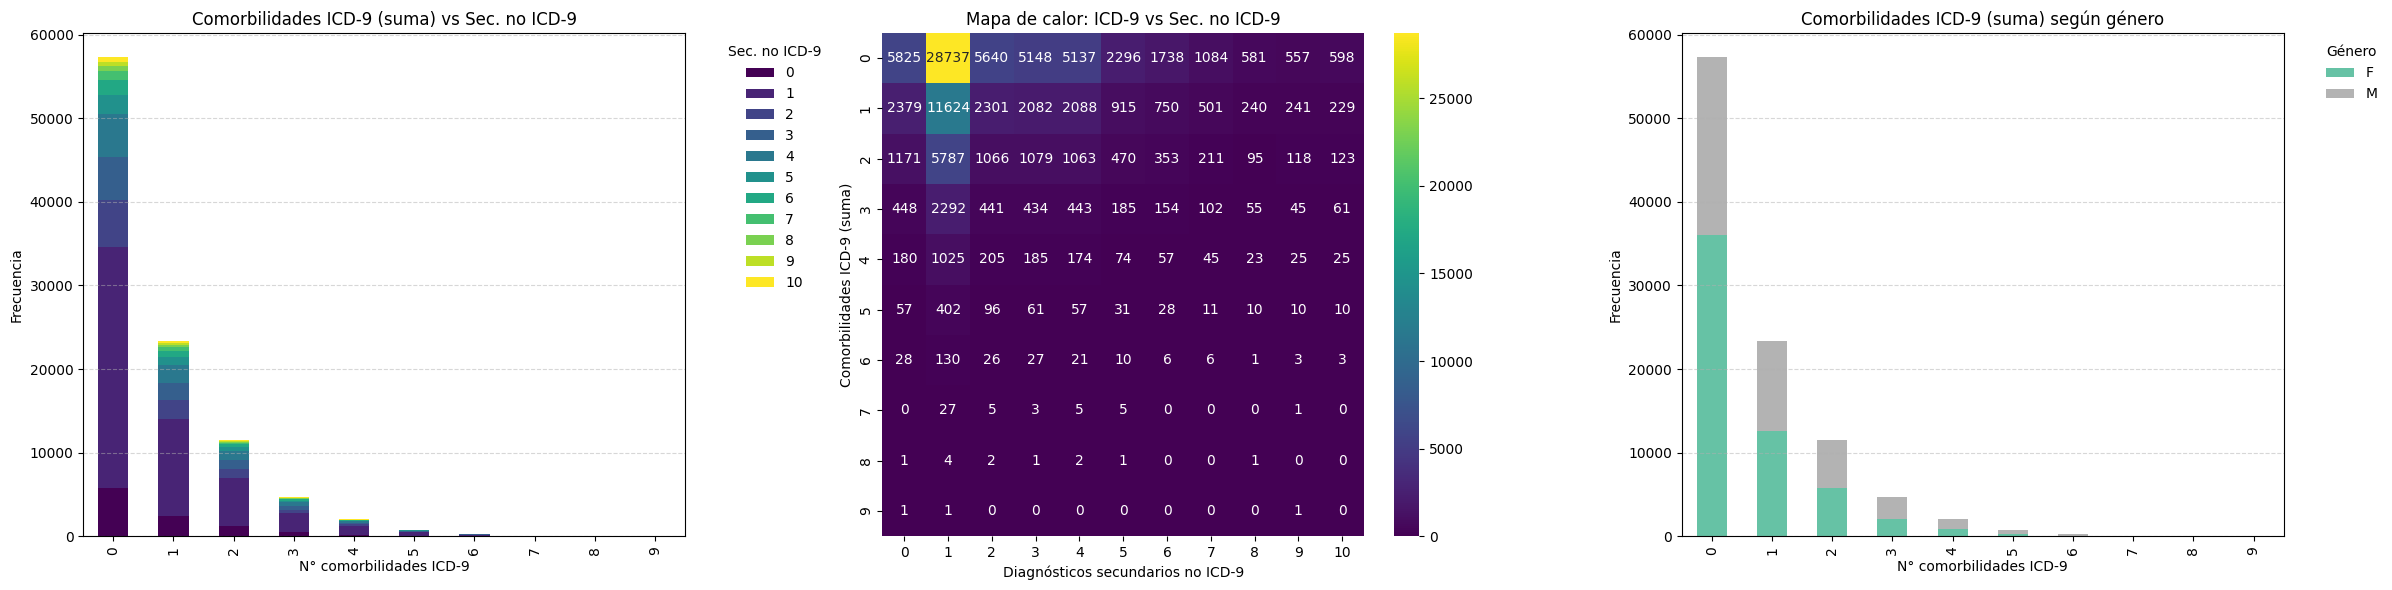

In [19]:
# --- Visualización conjunta ---
fig, axs = plt.subplots(1, 3, figsize=(24, 6))

# Barras apiladas ICD-9 vs Sec. no ICD-9
tabla1.plot(kind="bar", stacked=True, colormap="viridis", ax=axs[0])
axs[0].set_title("Comorbilidades ICD-9 (suma) vs Sec. no ICD-9")
axs[0].set_xlabel("N° comorbilidades ICD-9")
axs[0].set_ylabel("Frecuencia")
axs[0].grid(axis='y', linestyle='--', alpha=0.5)
axs[0].legend(title="Sec. no ICD-9", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

# Mapa de calor ICD-9 vs Sec. no ICD-9
sns.heatmap(tabla1, annot=True, fmt="d", cmap="viridis", ax=axs[1])
axs[1].set_title("Mapa de calor: ICD-9 vs Sec. no ICD-9")
axs[1].set_xlabel("Diagnósticos secundarios no ICD-9")
axs[1].set_ylabel("Comorbilidades ICD-9 (suma)")

# Barras apiladas ICD-9 vs Género
tabla2.plot(kind="bar", stacked=True, colormap="Set2", ax=axs[2])
axs[2].set_title("Comorbilidades ICD-9 (suma) según género")
axs[2].set_xlabel("N° comorbilidades ICD-9")
axs[2].set_ylabel("Frecuencia")
axs[2].grid(axis='y', linestyle='--', alpha=0.5)
axs[2].legend(title="Género", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

### Interpretación

**ICD-9 vs Diagnósticos secundarios no ICD-9**  
Chi2 = 120.73, p-valor = 0.017 (< 0.05), gl = 90.  
El valor de chi2 es relativamente grande y el p-valor es menor que 0.05, por lo que se rechaza la hipótesis de independencia. Esto significa que existe una relación significativa entre el número de comorbilidades ICD-9 y los diagnósticos secundarios no ICD-9. En términos prácticos, a mayor número de comorbilidades principales, mayor tiende a ser el número de diagnósticos secundarios, lo cual refleja la complejidad clínica de los pacientes.

**ICD-9 vs Género**  
Chi2 = 1938.26, p-valor = 0.000 (< 0.05), gl = 9.  
El valor de chi2 es muy alto y el p-valor prácticamente nulo, lo que permite rechazar claramente la hipótesis de independencia. Existe una asociación fuerte entre el número de comorbilidades ICD-9 y el género, lo que indica que hombres y mujeres presentan distribuciones diferentes de comorbilidades principales, posiblemente por factores biológicos, sociales o de atención médica.

**Conclusión**  
En ambos análisis, las variables no son independientes. Tanto el género como los diagnósticos secundarios están relacionados con la carga de comorbilidades ICD-9, lo que constituye un aspecto relevante para comprender mejor el perfil de los pacientes y planificar la atención hospitalaria.


Estadístico t: 22.055
p-valor: 0.0000


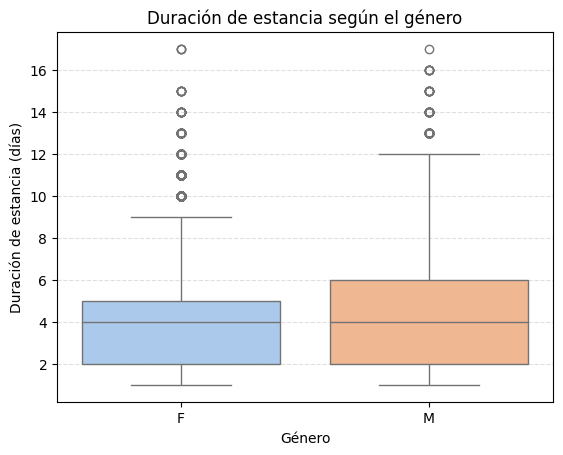

In [20]:
# --- Test t de Student ---
grupo_h = df_filtered[df_filtered['gender'] == 'M']['lengthofstay']
grupo_m = df_filtered[df_filtered['gender'] == 'F']['lengthofstay']

t_stat, p_val = ttest_ind(grupo_h, grupo_m, equal_var=True)

print(f"Estadístico t: {t_stat:.3f}")
print(f"p-valor: {p_val:.4f}")

# --- Visualización sin warning ---
sns.boxplot(data=df_filtered, x='gender', y='lengthofstay', hue='gender', palette='pastel', legend=False)
plt.title("Duración de estancia según el género")
plt.xlabel("Género")
plt.ylabel("Duración de estancia (días)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


### Interpretación
El gráfico evidencia una diferencia significativa en la duración media de la estancia hospitalaria entre hombres y mujeres.
El test t de Student (t = 22.06, p < 0.001) confirma que esta diferencia no es producto del azar.
Además, se observa una mayor dispersión en los valores superiores, indicando que algunos pacientes presentan estancias notablemente más largas.

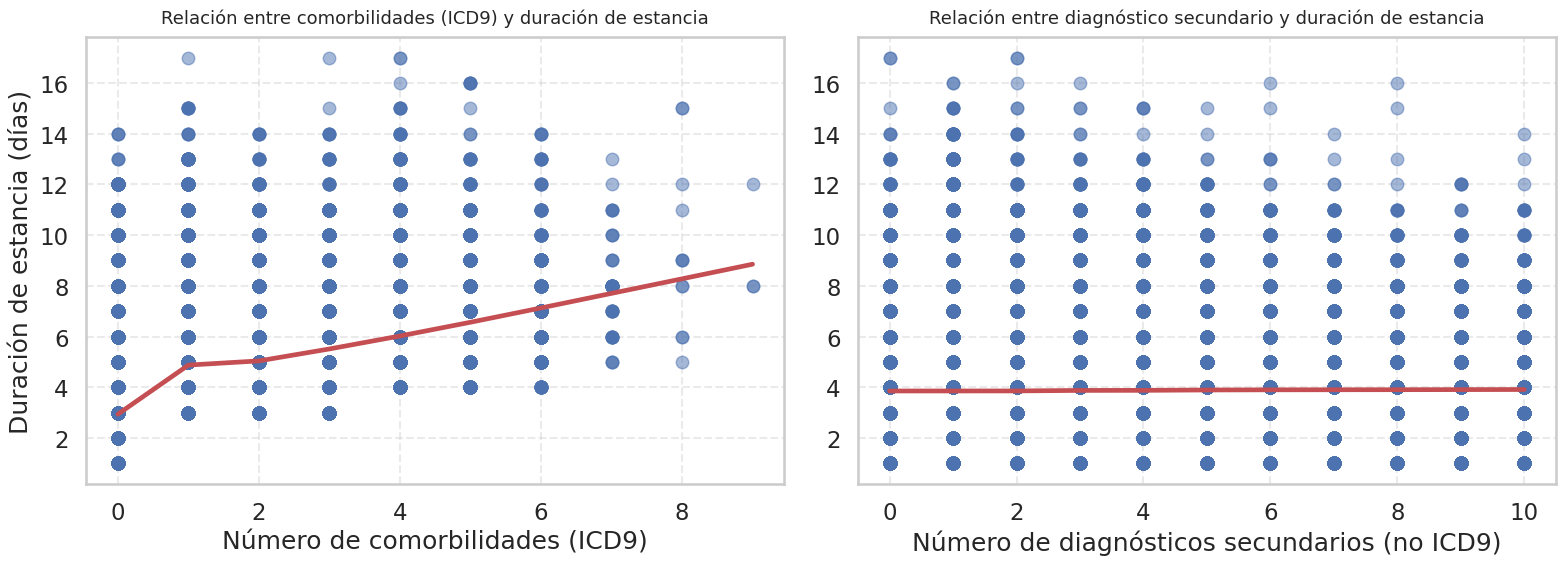

Comorbilidades → Spearman rho = 0.469, p-valor = 0.0000
Diagnóstico secundario → Spearman rho = 0.006, p-valor = 0.0713


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(
    data=df_filtered,
    x='icd9_comorbidity_sum',
    y='lengthofstay',
    ax=axes[0],
    scatter_kws={'alpha':0.5, 'color':'#4C72B0'},
    line_kws={'color':'#C44E52'},
    lowess=True
)
axes[0].set_title("Relación entre comorbilidades (ICD9) y duración de estancia", fontsize=13, pad=10)
axes[0].set_xlabel("Número de comorbilidades (ICD9)")
axes[0].set_ylabel("Duración de estancia (días)")
axes[0].grid(linestyle='--', alpha=0.4)

sns.regplot(
    data=df_filtered,
    x='secondarydiagnosisnonicd9',
    y='lengthofstay',
    ax=axes[1],
    scatter_kws={'alpha':0.5, 'color':'#4C72B0'},
    line_kws={'color':'#C44E52'},
    lowess=True
)
axes[1].set_title("Relación entre diagnóstico secundario y duración de estancia", fontsize=13, pad=10)
axes[1].set_xlabel("Número de diagnósticos secundarios (no ICD9)")
axes[1].set_ylabel("")
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

rho1, p1 = spearmanr(df_filtered['icd9_comorbidity_sum'], df_filtered['lengthofstay'])
rho2, p2 = spearmanr(df_filtered['secondarydiagnosisnonicd9'], df_filtered['lengthofstay'])

print(f"Comorbilidades → Spearman rho = {rho1:.3f}, p-valor = {p1:.4f}")
print(f"Diagnóstico secundario → Spearman rho = {rho2:.3f}, p-valor = {p2:.4f}")


### Interpretación  

El primer gráfico muestra una **relación positiva clara** entre el número de **comorbilidades (ICD9)** y la **duración de la estancia hospitalaria**.  
El coeficiente de Spearman (ρ = 0.469, p < 0.001) confirma una **asociación significativa**, indicando que a mayor número de comorbilidades, mayor es la duración promedio del ingreso.  
Esto sugiere que la **complejidad clínica del paciente** influye directamente en el tiempo de hospitalización.  

En cambio, el segundo gráfico muestra una **correlación muy débil y no significativa** (ρ = 0.006, p = 0.071).  
Por tanto, la cantidad de diagnósticos secundarios **no parece asociarse de forma directa** con la duración del ingreso hospitalario.  


## III.C - Multivariadas

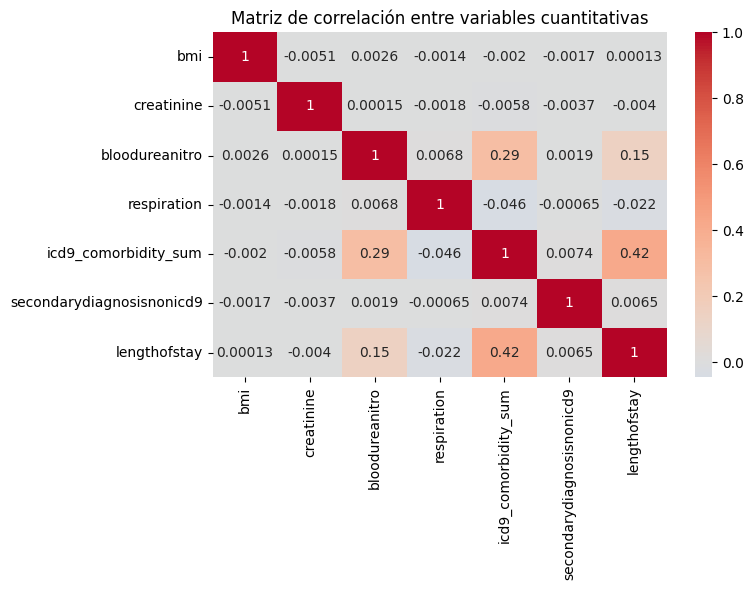

pve (por cp) y pve acumulada:
cp1: 21.60%  — cumul: 21.60%
cp2: 16.76%  — cumul: 38.36%
cp3: 16.71%  — cumul: 55.07%
cp4: 16.69%  — cumul: 71.76%
cp5: 16.54%  — cumul: 88.30%
cp6: 11.70%  — cumul: 100.00%
componentes para >= 70% : 4
componentes para >= 80% : 5
componentes para >= 90% : 6
broken-stick (componentes con var_exp > broken-stick): [np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
elbow (curvatura) recomienda: 5


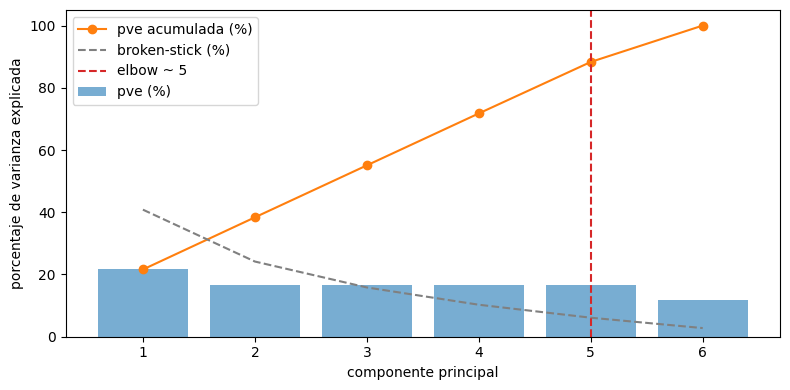


recomendaciones: threshold 80% -> 5, broken-stick -> 6, elbow -> 5
se usará n_comp = 5 (estrategia: elbow)


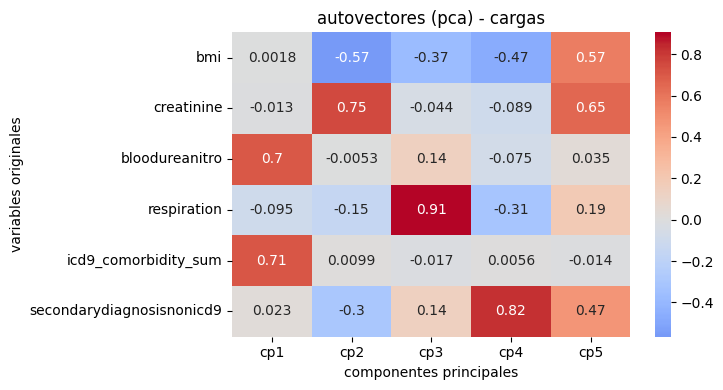

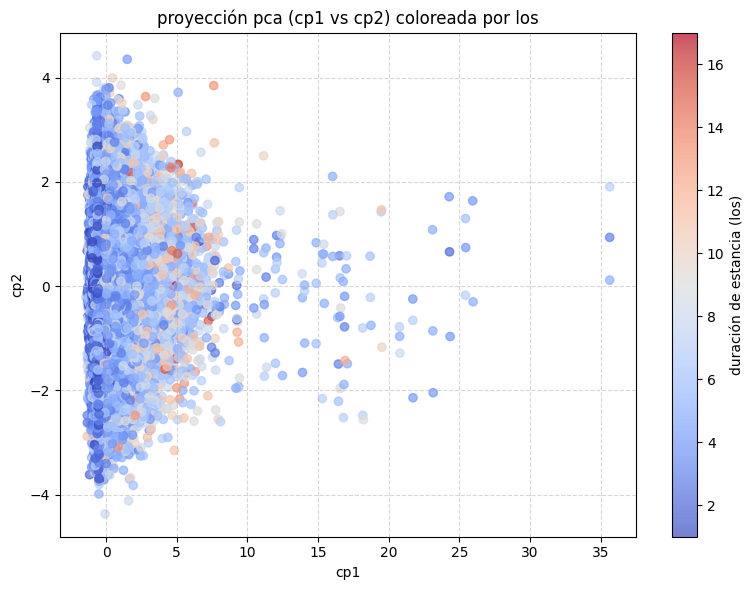

In [7]:
# Matriz de correlación entre variables cuantitativas
plt.figure(figsize=(8,6))
corr = df_filtered[['bmi', 'creatinine', 'bloodureanitro', 'respiration', 'icd9_comorbidity_sum', 'secondarydiagnosisnonicd9', 'lengthofstay']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables cuantitativas')
plt.tight_layout()
plt.show()

# vars pca
vars_pca = ['bmi', 'creatinine', 'bloodureanitro', 'respiration',
            'icd9_comorbidity_sum', 'secondarydiagnosisnonicd9']
df_pca = df_filtered.dropna(subset=vars_pca + ['lengthofstay'])

# estandarizar
X_std = StandardScaler().fit_transform(df_pca[vars_pca])

# pca completo para tests (pve, broken-stick, elbow)
pca_all = PCA().fit(X_std)
var_exp = pca_all.explained_variance_ratio_
cum_var = np.cumsum(var_exp)
m = len(var_exp)

# imprimir pve
print("pve (por cp) y pve acumulada:")
for i, (v, c) in enumerate(zip(var_exp, cum_var), start=1):
    print(f"cp{i}: {v*100:.2f}%  — cumul: {c*100:.2f}%")

# umbrales clásicos
for thresh in (0.70, 0.80, 0.90):
    n = int(np.searchsorted(cum_var, thresh) + 1)
    print(f"componentes para >= {int(thresh*100)}% : {n}")

# broken-stick
bs = np.array([sum([1.0/j for j in range(k, m+1)]) / m for k in range(1, m+1)])
keep_bs = np.where(var_exp > bs)[0] + 1
print("broken-stick (componentes con var_exp > broken-stick):", list(keep_bs))

# elbow (segunda derivada discreta)
sec_der = np.diff(cum_var, n=2)
if sec_der.size > 0:
    elbow_idx = int(np.argmax(np.abs(sec_der)) + 2)
    print("elbow (curvatura) recomienda:", elbow_idx)
else:
    elbow_idx = 1
    print("elbow no calculable -> 1")

# tracé scree + cumulative + broken-stick
plt.figure(figsize=(8,4))
plt.bar(np.arange(1,m+1), var_exp*100, alpha=0.6, label='pve (%)')
plt.plot(np.arange(1,m+1), cum_var*100, marker='o', color='C1', label='pve acumulada (%)')
plt.plot(np.arange(1,m+1), bs*100, '--', color='gray', label='broken-stick (%)')
plt.axvline(elbow_idx, color='C3', linestyle='--', label=f'elbow ~ {elbow_idx}')
plt.xlabel('componente principal')
plt.ylabel('porcentaje de varianza explicada')
plt.legend()
plt.tight_layout()
plt.show()

# función recomendación
def recommend(n_strategy='elbow', threshold=0.8):
    if n_strategy == 'threshold':
        return int(np.searchsorted(cum_var, threshold) + 1)
    if n_strategy == 'broken-stick':
        return int(keep_bs.max()) if keep_bs.size>0 else 1
    if n_strategy == 'elbow':
        return int(elbow_idx)
    raise ValueError("strategy must be 'threshold'|'broken-stick'|'elbow'")

# elegir estrategia aqui (cambiar si necesario)
n_strategy = 'elbow'   
threshold_val = 0.8    

n_comp = recommend(n_strategy, threshold_val)
print(f"\nrecomendaciones: threshold 80% -> {recommend('threshold',0.8)}, broken-stick -> {recommend('broken-stick')}, elbow -> {recommend('elbow')}")
print(f"se usará n_comp = {n_comp} (estrategia: {n_strategy})")

# ejecutar pca con n_comp
pca = PCA(n_components=n_comp).fit(X_std)
comps = pca.transform(X_std)

cols = [f'cp{i+1}' for i in range(n_comp)]
comps_df = pd.DataFrame(pca.components_.T, index=vars_pca, columns=cols)


plt.figure(figsize=(max(6, n_comp*1.5), 4))
sns.heatmap(comps_df, annot=True, cmap='coolwarm', center=0)
plt.title('autovectores (pca) - cargas')
plt.ylabel('variables originales')
plt.xlabel('componentes principales')
plt.tight_layout()
plt.show()

# proyección: si hay al menos 2 componentes, graficar cp1 vs cp2; si no, 1d
if n_comp >= 2:
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(comps[:,0], comps[:,1], c=df_pca['lengthofstay'], cmap='coolwarm', alpha=0.7)
    plt.xlabel("cp1")
    plt.ylabel("cp2")
    plt.title("proyección pca (cp1 vs cp2) coloreada por los")
    cbar = plt.colorbar(scatter)
    cbar.set_label("duración de estancia (los)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(8,3))
    sns.histplot(comps[:,0], kde=True, color='steelblue')
    plt.xlabel('cp1')
    plt.title('distribución cp1')
    plt.tight_layout()
    plt.show()

### Interpretación

En un primer análisis considerando solo **2 componentes principales (CP1 y CP2)**, se observaban los siguientes puntos:

- La variable **`lengthofstay`** (duración de estancia) aparecía principalmente asociada al número de **comorbilidades (`icd9_comorbidity_sum`)** y, en menor medida, a **`bloodureanitro`**.  
- La **Componente Principal 1 (CP1)** agrupaba sobre todo estas dos variables y reflejaba la **carga clínica global del paciente**, mostrando una relación clara con la duración de la hospitalización.  
- La **Componente Principal 2 (CP2)** estaba dominada por `creatinine` y `bmi`, representando un eje más **metabólico/nutricional**, con una influencia secundaria en la estancia.

Sin embargo, al aplicar un criterio más riguroso basado en la **Proporción de Varianza Explicada (PVE)**, se recomienda considerar más componentes.  
La PVE se utiliza para decidir cuántos componentes retener, siendo una práctica común elegir el número de componentes que explican al menos el **70–90% de la varianza total** (Jolliffe & Cadima, 2016).  

En este caso:  
- 4 componentes explican el 71.7% de la varianza acumulada,  
- 5 componentes alcanzan el 88.3%,  
- y 6 componentes explican el 100%.  

De acuerdo con la estrategia del **"elbow"**, se seleccionaron **5 componentes principales**.

### Con 5 componentes principales:

- La **CP1** sigue capturando la variabilidad ligada a **`bloodureanitro`** e **`icd9_comorbidity_sum`**, confirmando su rol central en la carga clínica.  
- La **CP2** está fuertemente asociada a **`creatinine`**, representando un eje **renal/metabólico**.  
- La **CP3** se asocia principalmente a la variable de **respiración (`respiration`)**, incorporando un eje **respiratorio**.  
- La **CP4** está dominada por el diagnóstico secundario **(`secondarydiagnosisnonicd9`)**, que añade un eje de **complejidad diagnóstica**.  
- La **CP5** integra en parte el efecto del **IMC (`bmi`)**, aportando un componente más **heterogéneo**.

### Resumen

- Con solo 2 componentes, la interpretación se centraba en la **carga clínica global** y en un eje secundario metabólico.  
- Con 5 componentes (88.3% de varianza explicada), la visión es más completa: además de la carga clínica y metabólica, se incorporan ejes **respiratorio, diagnósticos secundarios e IMC**, que aunque tengan menor peso individual, contribuyen a explicar mejor la variabilidad entre pacientes.  
- Esto sugiere que la **duración de la estancia hospitalaria** no depende únicamente de las comorbilidades y el nivel de urea, sino también de factores respiratorios, metabólicos y diagnósticos adicionales.


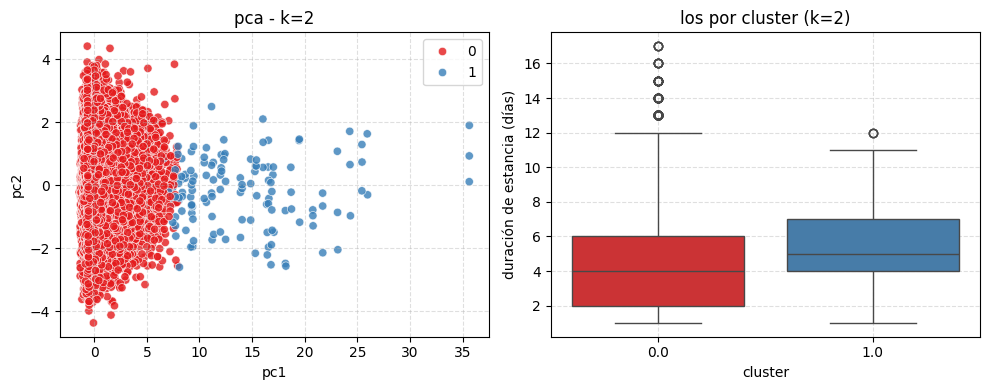

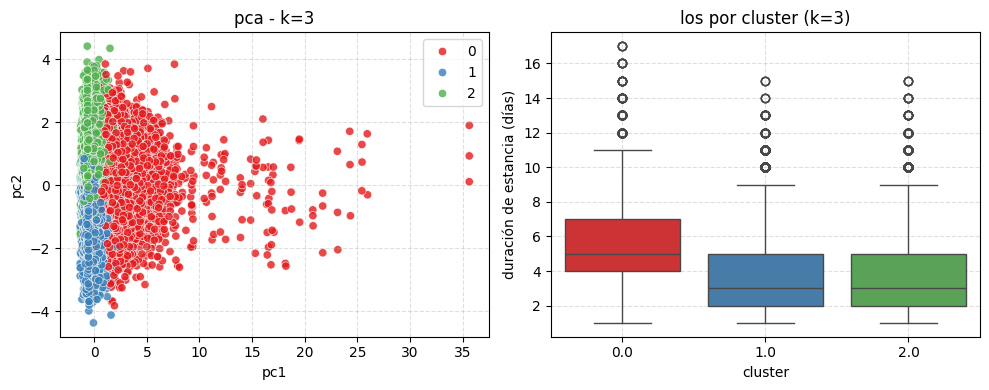

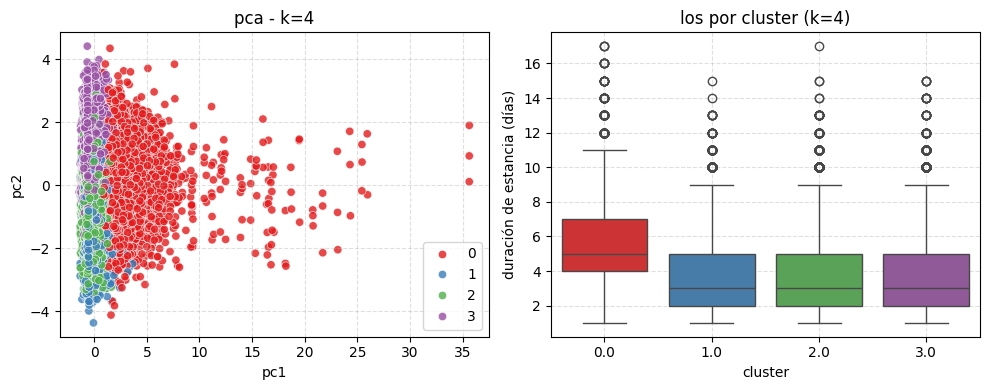

In [8]:
# seleccionar y estandarizar
vars_cluster = ['bmi', 'creatinine', 'bloodureanitro', 'respiration', 'icd9_comorbidity_sum', 'secondarydiagnosisnonicd9']
X = df_filtered.dropna(subset=vars_cluster)[vars_cluster]
X_std = StandardScaler().fit_transform(X)

# probar varios k (2,3,4)
for k in [2, 3, 4]:
    # ejecutar k-means y guardar etiquetas
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_std)
    col = f'cluster_{k}'
    df_filtered.loc[X.index, col] = clusters

    # pca para visualización
    pca = PCA(n_components=2)
    comps = pca.fit_transform(X_std)

    # paleta con k colores
    palette = sns.color_palette("Set1", n_colors=k)

    # scatter en plano pca (colores visibles)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.scatterplot(x=comps[:,0], y=comps[:,1], hue=clusters, palette=palette, legend='full', alpha=0.8)
    plt.title(f'pca - k={k}')
    plt.xlabel('pc1')
    plt.ylabel('pc2')
    plt.grid(True, linestyle='--', alpha=0.4)

    # boxplot por cluster (hue usado para evitar warning, luego quitamos leyenda)
    plt.subplot(1,2,2)
    ax = sns.boxplot(x=col, y='lengthofstay', data=df_filtered, hue=col, palette=palette, dodge=False)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    plt.title(f'los por cluster (k={k})')
    plt.xlabel('cluster')
    plt.ylabel('duración de estancia (días)')
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

### Interpretación del clustering

Se probó el algoritmo *K-means* con diferentes números de clústeres (k=2, 3 y 4) sobre las variables clínicas seleccionadas.

- Con **k=2**, los pacientes se dividen claramente en dos grupos:  
  - En los **boxplots**, el Clúster 0 concentra la mayoría de las estancias largas, con una mediana superior y una dispersión más amplia.  
  - El Clúster 1 muestra estancias significativamente más cortas, con menos variabilidad.  
  Esta separación en dos perfiles principales (estancia corta vs. estancia larga) es simple y muy interpretable.

- Con **k=3**, los boxplots revelan que los Clústeres 1 y 2 tienen distribuciones de duración muy similares (ambos centrados en estancias cortas), mientras que el Clúster 0 sigue captando los casos de estancia larga. La segmentación adicional no aporta mucho valor práctico.

- Con **k=4**, las diferencias entre boxplots se diluyen aún más: tres clústeres con estancias cortas muy parecidas y uno con estancias largas. La interpretación se vuelve redundante y menos útil.

**Conclusión:**  
El modelo con **k=2** es el más adecuado, ya que los boxplots muestran una separación clara entre pacientes de **estancia corta** y de **estancia prolongada**, lo que coincide con el objetivo de analizar los determinantes de la duración de hospitalización.


# IV - Detección y análisis de valores atípicos (Outliers)

En esta sección estudiaremos los valores atípicos presentes en el dataset, con especial atención a la variable **Blood Urea Nitrogen**, donde ya se han observado valores anómalos. Además, se analizará la **frecuencia respiratoria**, ya que en el análisis univariado se detectaron valores muy alejados de la media y posibles registros extremos que requieren una revisión detallada.

Se aplicarán varios métodos de detección para contrastar resultados:  
- **IQR (Rango Intercuartílico)**  
- **Z-score**  
- **DBSCAN**  

> **Nota:**  
> No aplicaremos la prueba de Grubbs en nuestro caso, ya que el dataset es demasiado grande y no cumple con las condiciones ideales para este test.  
> La prueba de Grubbs:
> - Requiere que los datos provengan de una distribución normal.
> - Está diseñada para detectar un solo atípico por prueba; si se sospechan múltiples, se deben aplicar versiones iterativas.
> - Es más confiable en muestras pequeñas o moderadas, donde otros métodos pueden perder sensibilidad.
> - Puede ser menos adecuada en grandes bases de datos o con distribuciones no normales.
>
> Por estas razones, no se utilizará Grubbs en este análisis.

⚠️ **Advertencia:**  
Aunque tenía previsto aplicar también el método **DBSCAN** para la detección de outliers, en la práctica **no fue posible ejecutarlo sobre las 100,000 muestras del dataset debido a limitaciones de memoria RAM**. El cuaderno de Jupyter se bloqueaba o quedaba sin respuesta al intentar procesar un volumen tan grande de datos con este algoritmo. Por lo tanto, el análisis de outliers se basa únicamente en los métodos IQR y Z-score.

A partir de estas técnicas se identificarán los outliers, se analizarán sus posibles causas (errores de registro, eventos poco frecuentes o variabilidad natural) y se decidirá su tratamiento más adecuado: **eliminación, corrección o mantenimiento**.

[IQR] Q1 = 11.00, Q3 = 14.00, IQR = 3.00
[IQR] Límite inferior = 6.50, Límite superior = 18.50
[IQR] Número de outliers detectados: 19592
[Z-score] Umbral: ±3
[Z-score] Número de outliers detectados: 1025


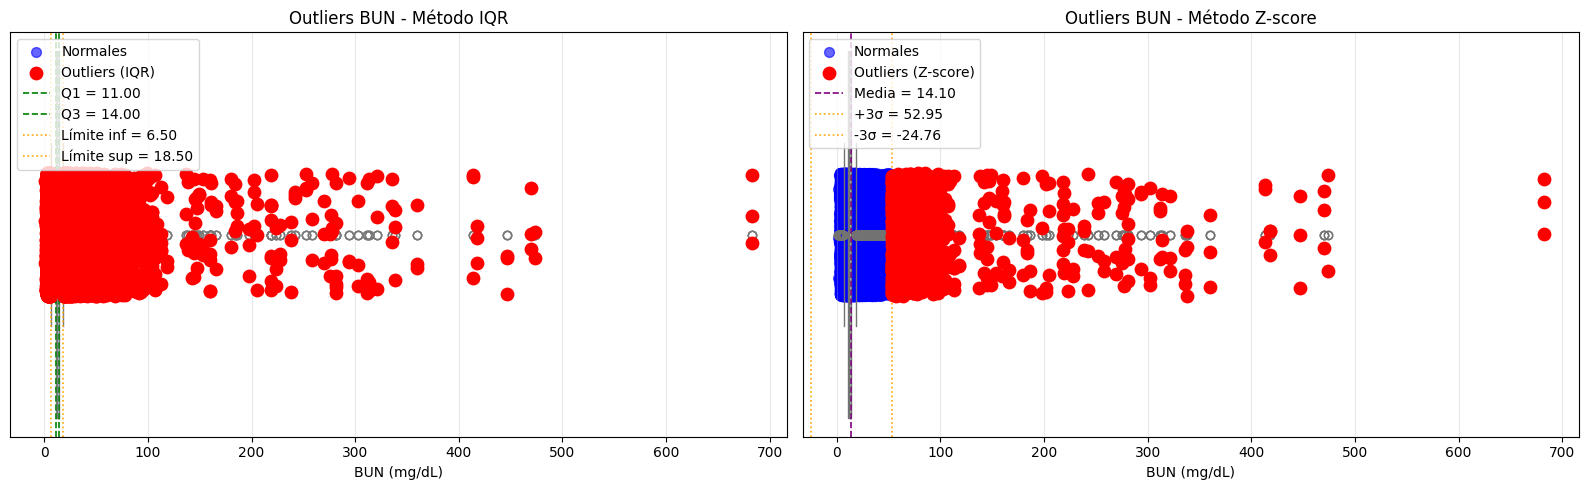

In [9]:
bun = df_filtered['bloodureanitro'].dropna().values

Q1 = np.percentile(bun, 25)
Q3 = np.percentile(bun, 75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers_iqr = bun[(bun < limite_inferior) | (bun > limite_superior)]
normales_iqr = bun[(bun >= limite_inferior) & (bun <= limite_superior)]

z_scores = (bun - np.mean(bun)) / np.std(bun)
umbral = 3
outliers_z = bun[np.abs(z_scores) > umbral]
normales_z = bun[np.abs(z_scores) <= umbral]

print(f"[IQR] Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"[IQR] Límite inferior = {limite_inferior:.2f}, Límite superior = {limite_superior:.2f}")
print(f"[IQR] Número de outliers detectados: {len(outliers_iqr)}")
print(f"[Z-score] Umbral: ±{umbral}")
print(f"[Z-score] Número de outliers detectados: {len(outliers_z)}")

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x=bun, color="lightblue", width=0.3, ax=axs[0])
axs[0].scatter(normales_iqr, np.random.uniform(-0.05, 0.05, size=len(normales_iqr)),
               color="blue", s=50, alpha=0.6, label="Normales")
axs[0].scatter(outliers_iqr, np.random.uniform(-0.05, 0.05, size=len(outliers_iqr)),
               color="red", s=80, zorder=5, label="Outliers (IQR)")
axs[0].axvline(Q1, color="green", linestyle="--", linewidth=1.2, label=f"Q1 = {Q1:.2f}")
axs[0].axvline(Q3, color="green", linestyle="--", linewidth=1.2, label=f"Q3 = {Q3:.2f}")
axs[0].axvline(limite_inferior, color="orange", linestyle=":", linewidth=1.2, label=f"Límite inf = {limite_inferior:.2f}")
axs[0].axvline(limite_superior, color="orange", linestyle=":", linewidth=1.2, label=f"Límite sup = {limite_superior:.2f}")
axs[0].set_title("Outliers BUN - Método IQR")
axs[0].set_xlabel("BUN (mg/dL)")
axs[0].set_yticks([])
axs[0].legend(loc="upper left")
axs[0].grid(alpha=0.3, axis="x")

sns.boxplot(x=bun, color="lightgreen", width=0.3, ax=axs[1])
axs[1].scatter(normales_z, np.random.uniform(-0.05, 0.05, size=len(normales_z)),
               color="blue", s=50, alpha=0.6, label="Normales")
axs[1].scatter(outliers_z, np.random.uniform(-0.05, 0.05, size=len(outliers_z)),
               color="red", s=80, zorder=5, label="Outliers (Z-score)")
axs[1].axvline(np.mean(bun), color="purple", linestyle="--", linewidth=1.2, label=f"Media = {np.mean(bun):.2f}")
axs[1].axvline(np.mean(bun) + umbral*np.std(bun), color="orange", linestyle=":", linewidth=1.2, label=f"+{umbral}σ = {(np.mean(bun)+umbral*np.std(bun)):.2f}")
axs[1].axvline(np.mean(bun) - umbral*np.std(bun), color="orange", linestyle=":", linewidth=1.2, label=f"-{umbral}σ = {(np.mean(bun)-umbral*np.std(bun)):.2f}")
axs[1].set_title("Outliers BUN - Método Z-score")
axs[1].set_xlabel("BUN (mg/dL)")
axs[1].set_yticks([])
axs[1].legend(loc="upper left")
axs[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

### Interpretación

Al aplicar los métodos clásicos de detección de outliers sobre la variable **BUN (Blood Urea Nitrogen)**, se observa lo siguiente:

- **[IQR]** Q1 = 11.00, Q3 = 14.00, IQR = 3.00  
  Límite inferior = 6.50, Límite superior = 18.50  
  **Número de outliers detectados (IQR): 19,592**
- **[Z-score]** Umbral: ±3  
  **Número de outliers detectados (Z-score): 1,025**

Dado que el dataset contiene 100,000 pacientes, el método IQR identifica casi el 20% de los valores como atípicos, lo cual es una proporción muy alta. Esto indica que el método IQR, en este contexto clínico, no discrimina solo errores o registros anómalos, sino que está capturando una variabilidad real de la población hospitalaria.

Según la literatura médica, los valores normales de BUN en adultos suelen estar entre 7 y 20 mg/dL. Valores superiores a 20 mg/dL pueden indicar insuficiencia renal, deshidratación u otras patologías, pero no necesariamente son errores. En un hospital, especialmente en pacientes graves, es esperable encontrar muchos valores elevados de BUN.

Además, el análisis de componentes principales mostró que el BUN es una de las variables que más contribuye a la **Componente Principal 1 (CP1)**, que explica una parte importante de la variabilidad y está asociada a la carga clínica del paciente.

Por lo tanto, aunque estadísticamente muchos valores aparecen como "outliers", desde el punto de vista clínico **no deben eliminarse ni tratarse como errores**, sino interpretarse como indicadores de gravedad o insuficiencia renal. Estos valores extremos aportan información clave sobre los pacientes más graves y son fundamentales para el análisis y la predicción de la estancia hospitalaria.

**Conclusión:**  
La alta proporción de "outliers" detectados refleja la heterogeneidad clínica real de la población y no errores de medición. Los valores elevados de BUN son esperados y relevantes, y deben mantenerse en el análisis.

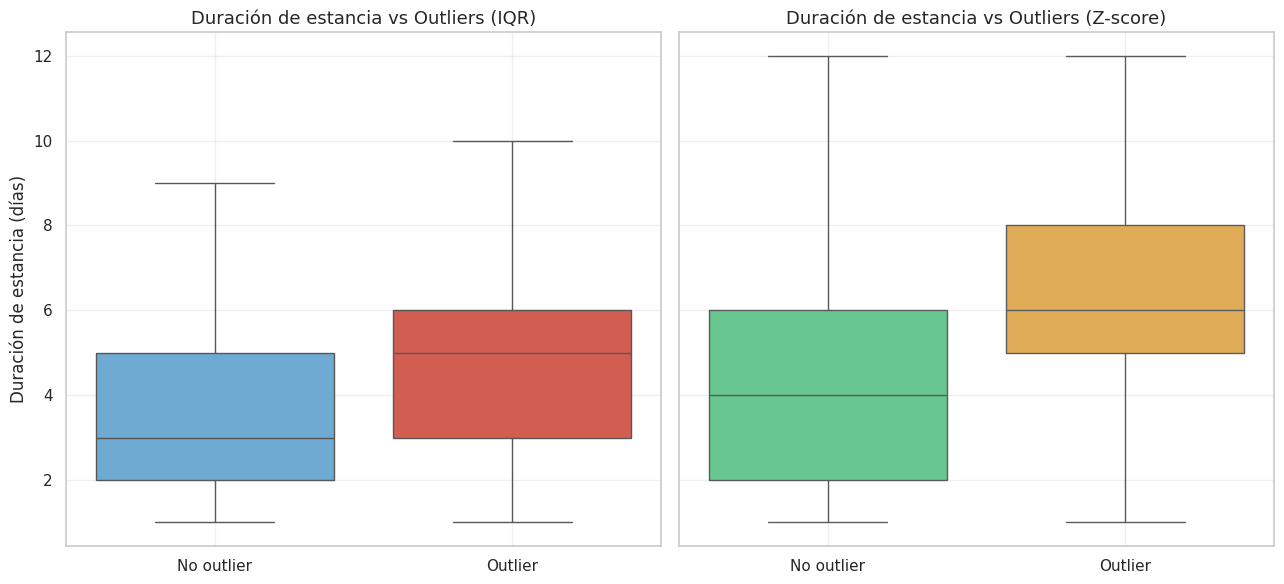


Resumen comparativo de la duración de estancia (días):

→ Método IQR:
            mean  median   max
is_outlier                    
No outlier  3.79     3.0  15.0
Outlier     4.85     5.0  17.0

→ Método Z-score:
            mean  median   max
is_outlier                    
No outlier  3.97     4.0  17.0
Outlier     6.63     6.0  17.0


In [24]:
bun = df_filtered['bloodureanitro'].dropna().values

# --- Método IQR ---
Q1, Q3 = np.percentile(bun, [25, 75])
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

df_iqr = df_filtered[['bloodureanitro', 'lengthofstay']].dropna().copy()
df_iqr['is_outlier'] = np.where((df_iqr['bloodureanitro'] < lim_inf) | (df_iqr['bloodureanitro'] > lim_sup), 'Outlier', 'No outlier')

# --- Método Z-score ---
df_z = df_filtered[['bloodureanitro', 'lengthofstay']].dropna().copy()
z_scores = (df_z['bloodureanitro'] - df_z['bloodureanitro'].mean()) / df_z['bloodureanitro'].std()
df_z['is_outlier'] = np.where(np.abs(z_scores) > 3, 'Outlier', 'No outlier')

# --- Gráficos ---
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

sns.boxplot(
    data=df_iqr,
    hue='is_outlier',
    x='is_outlier',
    y='lengthofstay',
    palette={'No outlier': '#5DADE2', 'Outlier': '#E74C3C'},
    ax=axes[0],
    showfliers=False,
    legend=False
)
axes[0].set_title("Duración de estancia vs Outliers (IQR)", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Duración de estancia (días)")
axes[0].grid(alpha=0.3)

sns.boxplot(
    data=df_z,
    hue='is_outlier',
    x='is_outlier',
    y='lengthofstay',
    palette={'No outlier': '#58D68D', 'Outlier': '#F5B041'},
    ax=axes[1],
    showfliers=False,
    legend=False
)
axes[1].set_title("Duración de estancia vs Outliers (Z-score)", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

iqr_summary = df_iqr.groupby('is_outlier')['lengthofstay'].describe()[['mean', '50%', 'max']].rename(columns={'50%': 'median'})
z_summary = df_z.groupby('is_outlier')['lengthofstay'].describe()[['mean', '50%', 'max']].rename(columns={'50%': 'median'})

print("\nResumen comparativo de la duración de estancia (días):\n")
print("→ Método IQR:")
print(iqr_summary.round(2))
print("\n→ Método Z-score:")
print(z_summary.round(2))


### Interpretación  

El análisis comparativo de los outliers del nivel de **BUN (Blood Urea Nitrogen)** revela una tendencia clara:  
los pacientes identificados como **outliers** presentan una **mayor duración media y mediana de estancia hospitalaria** en comparación con los pacientes dentro del rango normal.  

Según el **método IQR**, los outliers tienen una estancia media de **4.85 días** frente a **3.79 días** en los no outliers,  
mientras que el **método Z-score** muestra una diferencia aún más marcada (**6.63 días** frente a **3.97 días**).  

Esto sugiere que las **altas concentraciones de BUN** (que reflejan un posible deterioro renal o una disfunción metabólica significativa)
están asociadas con **estancias hospitalarias más prolongadas**.  
Por tanto, los valores extremos de BUN **no deben considerarse como errores**, sino como **indicadores clínicos relevantes** que aportan información valiosa sobre la gravedad y evolución del paciente.  


[Z-score] Umbral: ±3
[Z-score] Número de outliers detectados: 2273


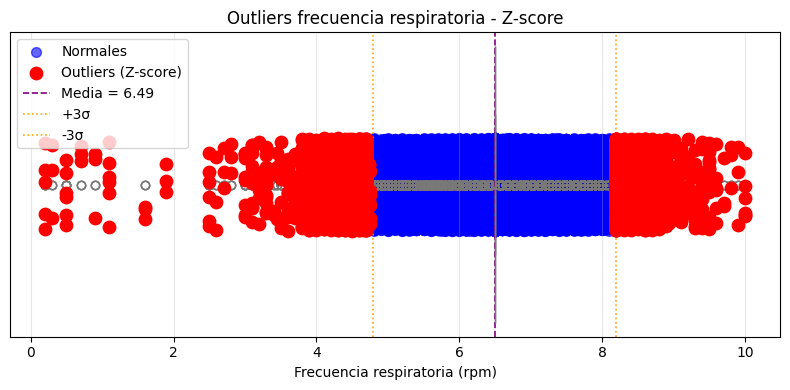

In [10]:
resp = df_filtered['respiration'].dropna().values

# --- Método Z-score ---
z_scores = (resp - np.mean(resp)) / np.std(resp)
seuil = 3  # umbral clásico, modificable
outliers_z = resp[np.abs(z_scores) > seuil]
normales_z = resp[np.abs(z_scores) <= seuil]

print(f"[Z-score] Umbral: ±{seuil}")
print(f"[Z-score] Número de outliers detectados: {len(outliers_z)}")

plt.figure(figsize=(8, 4))
sns.boxplot(x=resp, color="lightblue", width=0.3)
plt.scatter(normales_z, np.random.uniform(-0.05, 0.05, size=len(normales_z)),
            color="blue", s=50, alpha=0.6, label="Normales")
plt.scatter(outliers_z, np.random.uniform(-0.05, 0.05, size=len(outliers_z)),
            color="red", s=80, zorder=5, label="Outliers (Z-score)")
plt.axvline(np.mean(resp), color="purple", linestyle="--", linewidth=1.2, label=f"Media = {np.mean(resp):.2f}")
plt.axvline(np.mean(resp) + seuil*np.std(resp), color="orange", linestyle=":", linewidth=1.2, label=f"+{seuil}σ")
plt.axvline(np.mean(resp) - seuil*np.std(resp), color="orange", linestyle=":", linewidth=1.2, label=f"-{seuil}σ")
plt.title("Outliers frecuencia respiratoria - Z-score")
plt.xlabel("Frecuencia respiratoria (rpm)")
plt.yticks([])
plt.legend(loc="upper left")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### Interpretación

Al aplicar los métodos clásicos de detección de outliers sobre la variable **frecuencia respiratoria**, se observa lo siguiente:

- **[Z-score]** Umbral: ±3  
  **Número de outliers detectados (Z-score): 2,273**

Intenté también aplicar el método **IQR** (rango intercuartílico), pero en este caso **Q1 y Q3 resultaron iguales (Q1 = 6.5, Q3 = 6.5)**, lo que hace que el IQR sea cero y, por lo tanto, el método no sea aplicable ni útil para esta variable. Esto suele ocurrir cuando la variable está muy concentrada en un solo valor o tiene poca dispersión en los cuartiles.

Dado que el dataset contiene 100,000 pacientes, el método Z-score identifica un número moderado de valores como atípicos. Sin embargo, al igual que con el BUN, estos outliers **no deben considerarse errores de medición ni registros anómalos**, sino que reflejan la variabilidad clínica real de la población hospitalaria. En muchos casos, los valores extremos de frecuencia respiratoria corresponden a pacientes en situaciones clínicas graves o inusuales, y son precisamente estos casos los que aportan información clave para el análisis y la predicción de la estancia hospitalaria.

**Conclusión:**  
La presencia de "outliers" en la frecuencia respiratoria es esperada y relevante desde el punto de vista clínico. Estos valores extremos ayudan a identificar a los pacientes en peor estado y no deben eliminarse del análisis, ya que aportan información fundamental sobre la gravedad y la heterogeneidad de la población hospitalaria.

[Z-score] Umbral: ±3
[Z-score] Número de outliers detectados: 2273

Resumen comparativo de la duración de estancia (días):
                mean  median  max
is_outlier                       
False       3.964073     4.0   17
True        5.589969     5.0   14


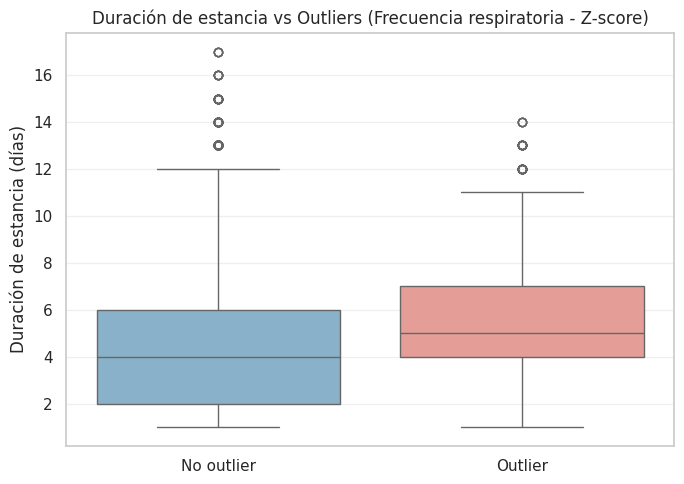

In [26]:
# --- Método Z-score para la frecuencia respiratoria ---
resp = df_filtered['respiration'].dropna().values

z_scores = (resp - np.mean(resp)) / np.std(resp)
umbral = 3
outliers_z = resp[np.abs(z_scores) > umbral]
normales_z = resp[np.abs(z_scores) <= umbral]

print(f"[Z-score] Umbral: ±{umbral}")
print(f"[Z-score] Número de outliers detectados: {len(outliers_z)}")

# Crear variable booleana de outlier en el DataFrame original
df_resp = df_filtered.copy()
df_resp = df_resp[df_resp['respiration'].notna()]
df_resp['is_outlier'] = np.abs((df_resp['respiration'] - df_resp['respiration'].mean()) / df_resp['respiration'].std()) > umbral

# Agrupar por tipo de caso y resumir duración de estancia
summary_resp = df_resp.groupby('is_outlier')['lengthofstay'].agg(['mean', 'median', 'max'])
print("\nResumen comparativo de la duración de estancia (días):")
print(summary_resp)

# --- Gráfico comparativo ---
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_resp,
    x='is_outlier',
    y='lengthofstay',
    hue='is_outlier',
    palette={False: "#7FB3D5", True: "#F1948A"},
    legend=False
)
plt.xticks([0, 1], ["No outlier", "Outlier"])
plt.title("Duración de estancia vs Outliers (Frecuencia respiratoria - Z-score)")
plt.xlabel("")
plt.ylabel("Duración de estancia (días)")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Interpretación  

El análisis de los outliers en la **frecuencia respiratoria** muestra un patrón interesante:  
los pacientes identificados como **outliers** presentan una **mayor duración media y mediana de estancia hospitalaria** en comparación con aquellos con valores dentro del rango normal.  

Según el **método Z-score** con un umbral de ±3:  
- Los **outliers** tienen una estancia media de **5.59 días** frente a **3.96 días** en los no outliers.  
- La mediana de estancia también es mayor en los outliers (**5 días** frente a **4 días**).  

Esto indica que las **frecuencias respiratorias extremadamente altas o bajas** podrían estar asociadas con una **mayor gravedad clínica**, reflejando condiciones que requieren una estancia hospitalaria más prolongada.  

Por lo tanto, estos valores extremos **no deberían considerarse como errores de medición**, sino como **marcadores clínicos importantes** que pueden ofrecer información relevante sobre la evolución y el riesgo del paciente.


## Conclusion

### Bilan général

Ce projet inaugure une plongée dans la complexité des données hospitalières, avec pour ambition de prédire la durée de séjour à partir d’un large éventail de variables cliniques et démographiques.

La démarche a débuté par une sélection rigoureuse des variables, guidée par la littérature scientifique et les recommandations de la communauté. Le nettoyage et l’analyse descriptive ont permis de mettre en lumière la structure des données : distributions asymétriques, présence d’outliers cliniquement pertinents, et hétérogénéité des mesures. Cette étape a été essentielle pour comprendre la réalité hospitalière, où les cas extrêmes sont souvent porteurs d’informations cruciales.

### Enseignements clés

L’analyse bivariée et multivariée a permis de dégager plusieurs enseignements :

- **Comorbidités et réadmissions** : Ce sont les moteurs principaux de la durée d’hospitalisation. Plus un patient cumule de pathologies ou de retours à l’hôpital, plus son séjour s’allonge et devient imprévisible. Les boxplots et corrélations confirment cette tendance.
- **Variables biologiques isolées** : IMC, créatinine, urée, respiration… prises séparément, elles n’expliquent pas suffisamment la durée du séjour. Une approche multivariable est indispensable pour saisir la complexité du phénomène.
- **Analyse en composantes principales (ACP)** : Les cinq premières composantes expliquent 88 % de la variance, réparties entre charge clinique, fonction rénale, respiration, diagnostics secondaires et IMC. Aucun facteur unique ne domine : la durée de séjour résulte d’une combinaison de dimensions cliniques.
- **Clustering K-means** : Deux grands profils émergent : les séjours courts, homogènes et fréquents, et les séjours longs, plus hétérogènes et cliniquement lourds. Une segmentation plus fine n’apporte pas de valeur supplémentaire : la distinction binaire est la plus pertinente pour la suite.

### Limites et points de vigilance

Malgré la robustesse de la démarche, certaines limites subsistent :

- **Faible variance expliquée** par les premières composantes (≈20 %) : cela souligne la dispersion de l’information et la complexité du phénomène étudié.
- **Absence de variables contextuelles majeures** : l’âge, le type d’admission, l’évolution clinique… autant d’éléments qui pourraient affiner la prédiction et enrichir l’analyse.
- **Mesures physiologiques parfois peu informatives** : certaines variables, comme le pouls ou certains paramètres sanguins, n’apportent pas de signal fort, ce qui limite la portée des conclusions.
- **Gestion des outliers** : Les méthodes statistiques classiques (IQR, Z-score) détectent de nombreux outliers, mais l’analyse clinique montre que beaucoup d’entre eux sont des cas réels et pertinents, notamment pour le BUN et la respiration. Il est donc crucial de ne pas éliminer ces valeurs sans discernement.

### Perspectives et pistes d’amélioration

Pour la suite, plusieurs axes sont envisagés :

1. **Affiner la gestion des outliers** : Combiner méthodes statistiques et expertise médicale pour distinguer les valeurs extrêmes pertinentes des erreurs de saisie.
2. **Développer des modèles prédictifs supervisés** : Mettre en place des ensembles d’entraînement, validation et test, et comparer différentes approches (régression, arbres, réseaux neuronaux).
3. **Évaluer la robustesse et l’interprétabilité des modèles** : Utiliser des métriques adaptées et des techniques de validation croisée pour garantir la fiabilité des résultats.

### Ouverture et synthèse

Cette première étape a permis de poser les bases méthodologiques pour une modélisation prédictive robuste et adaptée à la réalité hospitalière. La richesse et la complexité des données invitent à poursuivre l’exploration, en combinant rigueur statistique et regard clinique, pour aboutir à des outils d’aide à la décision réellement utiles pour la gestion hospitalière.

En résumé, la prédiction de la durée de séjour hospitalier est un défi multidimensionnel : il ne s’agit pas seulement d’analyser des chiffres, mais de comprendre les trajectoires de soins, les profils cliniques et les dynamiques propres à chaque patient. Ce projet ouvre la voie à une approche plus intégrative et personnalisée, où la donnée devient un levier pour améliorer l’organisation hospitalière et la qualité des soins.